# <center><strong>Social Media User Classification</strong></center>
----------------------------------------------------

#### **By Mohamed Jamyl**

http://linkedin.com/company/gray-matter-da

http://linkedin.com/in/mohamed-jamyl

https://www.kaggle.com/mohamedjamyl

https://github.com/Mohamed-Jamyl

-------------------------

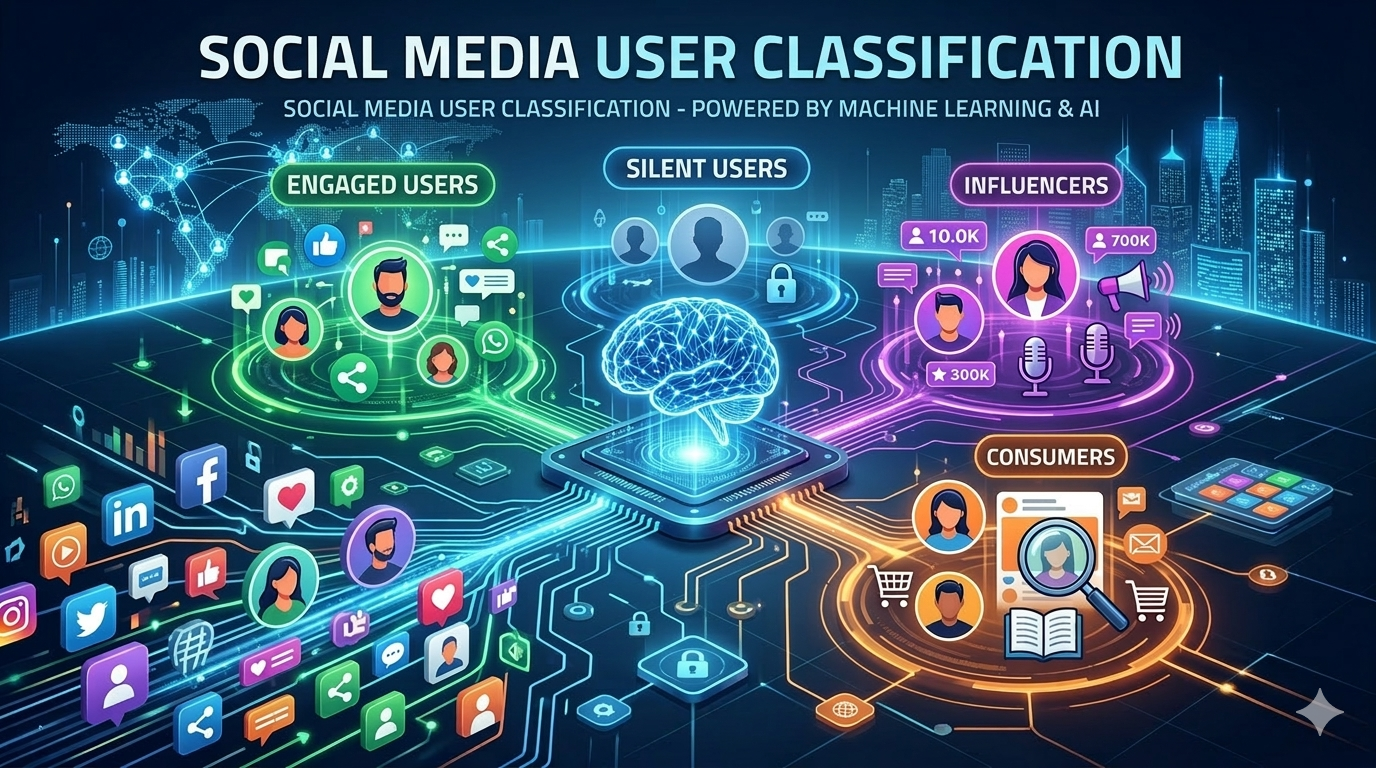

In [1]:
from IPython.display import Image
Image(filename='Logo.png')

--------------------------------
--------------------------------
## **Import Libraries**
--------------------------------

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras import callbacks
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.preprocessing import OneHotEncoder,StandardScaler,OrdinalEncoder

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import pickle
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

2026-04-09 17:45:07.245066: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775756707.560738      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775756707.638009      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775756708.242612      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775756708.242657      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775756708.242661      55 computation_placer.cc:177] computation placer alr

In [3]:
# import sklearn as sl
# import pickle as pl
# import sys
# print("Pandas version:", pd.__version__)
# print("NumPy version:", np.__version__)
# print("Scikit-learn version:", sl.__version__)
# print("TensorFlow version:", tf.__version__)
# print(sys.version)

---------------------------------------
---------------------------------------
---------------------------------------

### **Exploring Data**

 - **Data loading and Inspection**
 - **Data Types**
 - **Missing Values**
 - **Duplicates**

-------------------------

In [4]:
df = pd.read_csv('/kaggle/input/datasets/rockyt07/social-media-user-analysis/instagram_users_lifestyle.csv')
df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [5]:
df.shape

(1547896, 58)

In [6]:
df.columns

Index(['user_id', 'app_name', 'age', 'gender', 'country', 'urban_rural',
       'income_level', 'employment_status', 'education_level',
       'relationship_status', 'has_children', 'exercise_hours_per_week',
       'sleep_hours_per_night', 'diet_quality', 'smoking', 'alcohol_frequency',
       'perceived_stress_score', 'self_reported_happiness', 'body_mass_index',
       'blood_pressure_systolic', 'blood_pressure_diastolic',
       'daily_steps_count', 'weekly_work_hours', 'hobbies_count',
       'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'reels_watched_per_day',
       'stories_viewed_per_day', 'likes_given_per_day',
       'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

In [8]:
df.isnull().sum()

user_id                           0
app_name                          0
age                               0
gender                            0
country                           0
urban_rural                       0
income_level                      0
employment_status                 0
education_level                   0
relationship_status               0
has_children                      0
exercise_hours_per_week           0
sleep_hours_per_night             0
diet_quality                      0
smoking                           0
alcohol_frequency                 0
perceived_stress_score            0
self_reported_happiness           0
body_mass_index                   0
blood_pressure_systolic           0
blood_pressure_diastolic          0
daily_steps_count                 0
weekly_work_hours                 0
hobbies_count                     0
social_events_per_month           0
books_read_per_year               0
volunteer_hours_per_month         0
travel_frequency_per_year   

In [9]:
df.duplicated().sum()

np.int64(0)

----------------------------------------------
----------------------------------------------
## **Data Cleaning**
----------------------------------------------

In [10]:
df=df.drop('user_id',axis=1)

In [11]:
df['education_level'].value_counts()

education_level
Bachelor’s      541083
High school     387323
Some college    309922
Master’s        185651
Other            77295
PhD              37003
Secondary         4364
Bachelor          2650
High School       2605
Name: count, dtype: int64

In [12]:
df['education_level'] = df['education_level'].replace('Bachelor’s','Bachelor')
df['education_level'] = df['education_level'].replace('High School','High school')

In [13]:
df['education_level'].value_counts()

education_level
Bachelor        543733
High school     389928
Some college    309922
Master’s        185651
Other            77295
PhD              37003
Secondary         4364
Name: count, dtype: int64

In [14]:
df['smoking'] = df['smoking'].replace('Former','No')

In [15]:
df['smoking'].value_counts()

smoking
No     1314963
Yes     232933
Name: count, dtype: int64

----------------------------------
### **Basic Statistical Overview**
-------------------------------------------
- Summary Statistical : **describe()**
--------------------------------------

In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1547896.0,38.985440,15.294528,13.00,26.00,39.0,52.00,65.00
exercise_hours_per_week,1547896.0,7.143480,3.994556,0.00,4.00,6.6,9.70,24.10
sleep_hours_per_night,1547896.0,6.999384,1.097098,3.00,6.30,7.0,7.70,10.00
perceived_stress_score,1547896.0,19.987738,11.832578,0.00,10.00,20.0,30.00,40.00
self_reported_happiness,1547896.0,5.499804,2.871232,1.00,3.00,5.0,8.00,10.00
body_mass_index,1547896.0,25.000837,3.976188,15.00,22.30,25.0,27.70,45.00
blood_pressure_systolic,1547896.0,124.491714,20.206989,90.00,107.00,124.0,142.00,159.00
blood_pressure_diastolic,1547896.0,79.500074,11.548740,60.00,70.00,79.0,90.00,99.00
daily_steps_count,1547896.0,8000.104562,89.397615,7566.00,7940.00,8000.0,8060.00,8473.00
weekly_work_hours,1547896.0,36.222014,15.080632,0.00,30.50,38.7,46.00,80.00


In [17]:
df.select_dtypes('object').describe().T

,count,unique,top,freq
app_name,1547896,1,Instagram,1547896
gender,1547896,4,Male,743169
country,1547896,10,United States,386829
urban_rural,1547896,3,Urban,850754
income_level,1547896,5,Middle,465037
employment_status,1547896,7,Full-time employed,629798
education_level,1547896,7,Bachelor,543733
relationship_status,1547896,5,Single,670260
has_children,1547896,2,No,1156273
diet_quality,1547896,5,Average,543910


---------------------------------------------
## **Detect Outliers**
--------------------------------------------

In [18]:
# def detect_outliers(column) :
#     Q1=df[column].quantile(0.25)
#     Q3=df[column].quantile(0.75)
#     IQR = Q3-Q1

#     Lower_bound = Q1 - 1.5*IQR
#     Upper_bound = Q3 + 1.5*IQR
   
#     outliers=df.loc[(df[column] >= Upper_bound) | (df[column] <= Lower_bound)]
    
#     print(f"Upper bound: {upper_bound:.2f}")
#     print(f"Lower bound: {lower_bound:.2f}")    
#     print(f"Outliers: {len(outliers)}")

In [19]:
def boxplot(column):
    plt.figure(figsize=(12,5))
    sns.boxplot(x=column, data=df)
    plt.show()

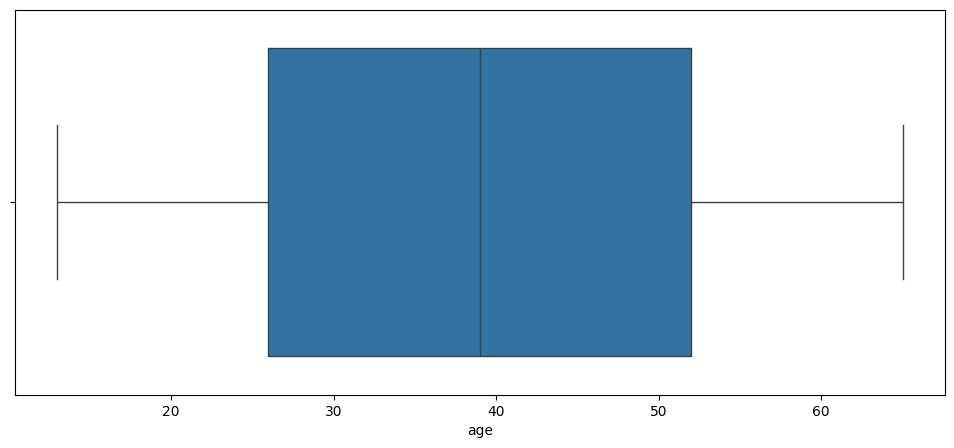

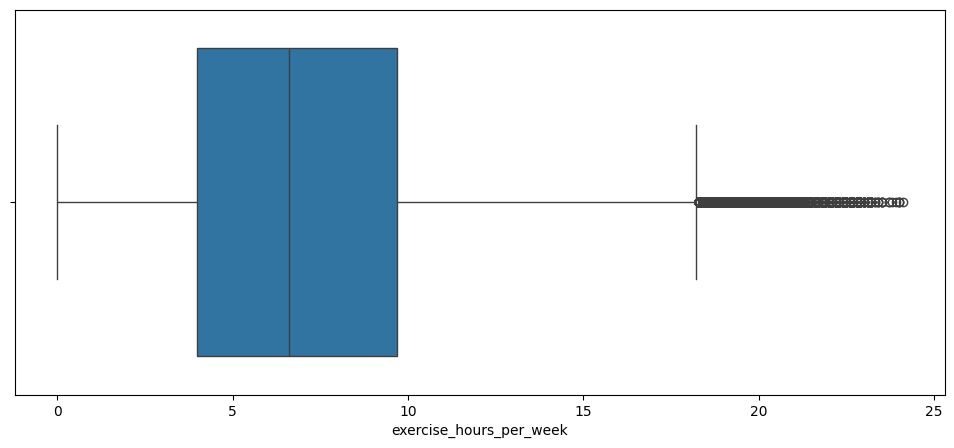

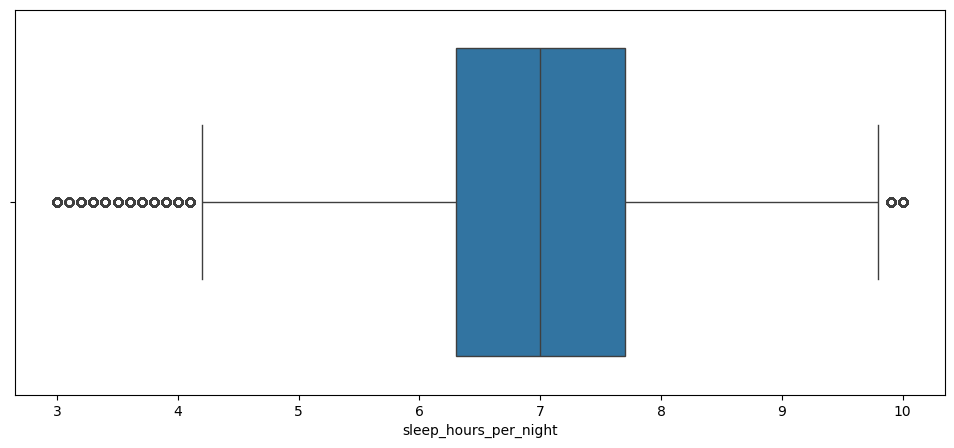

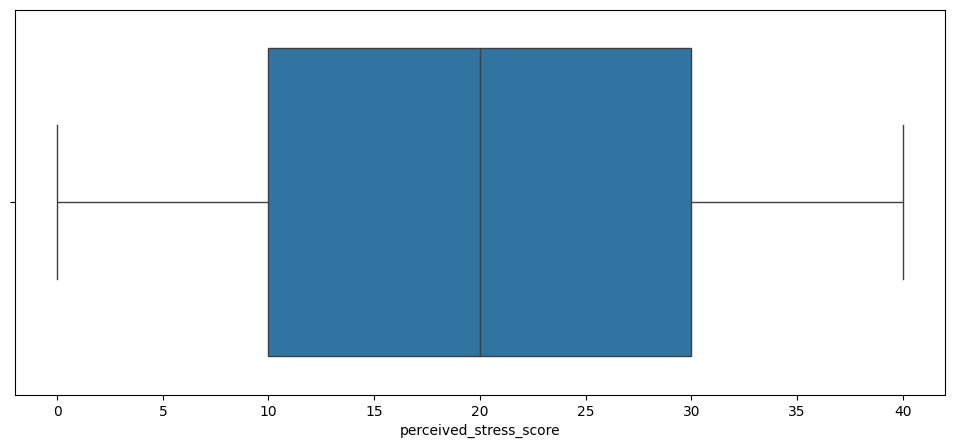

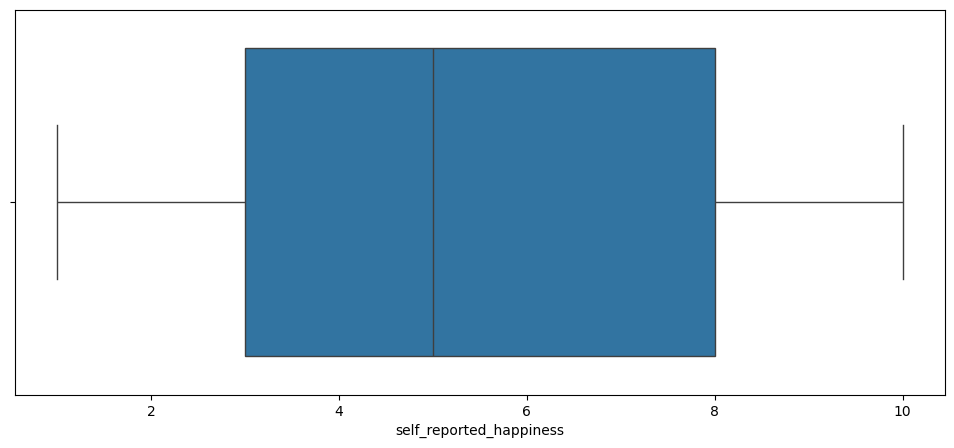

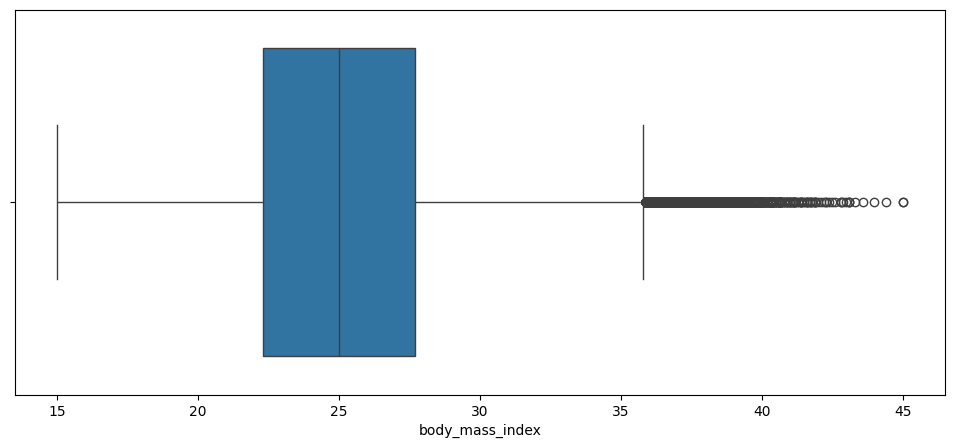

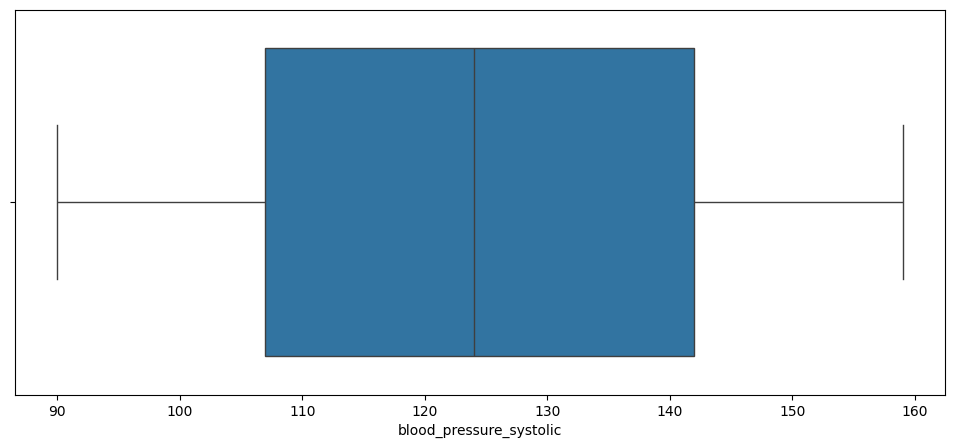

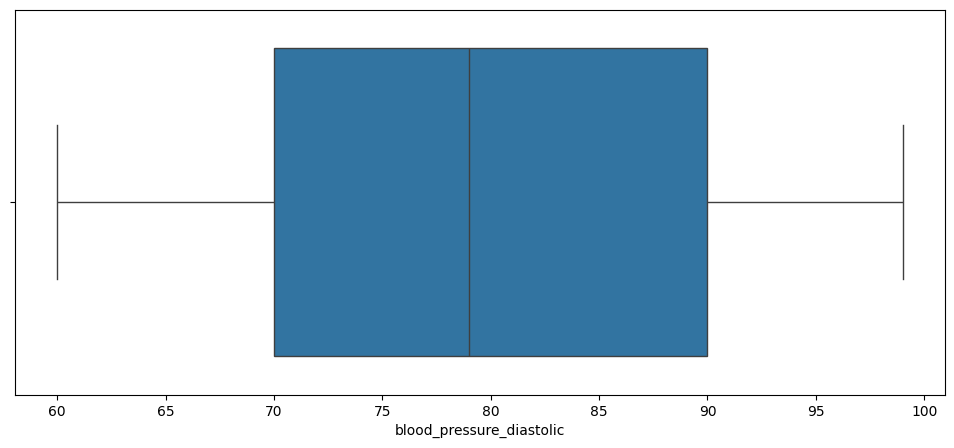

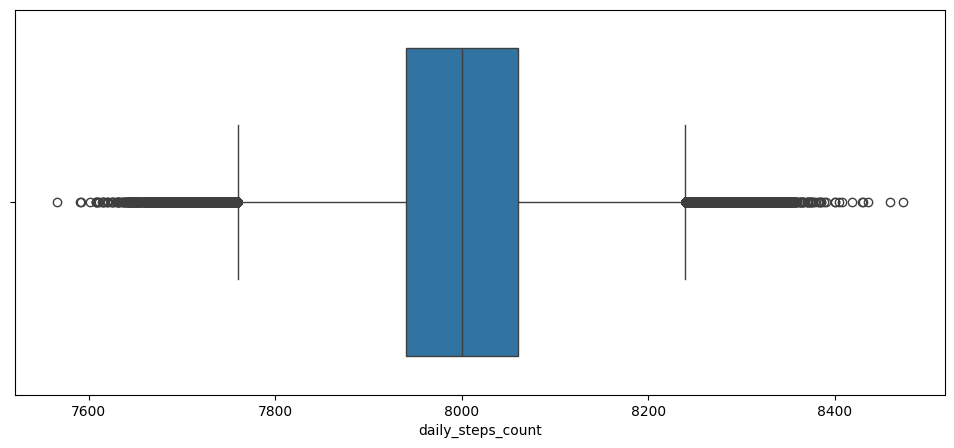

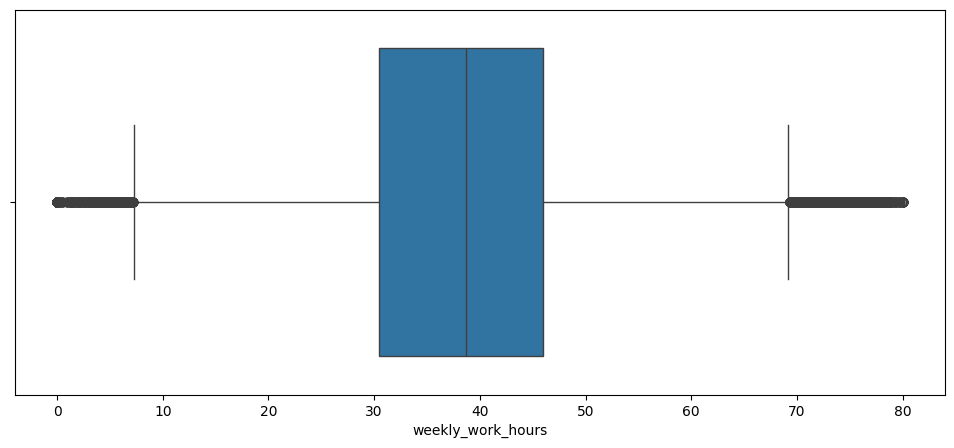

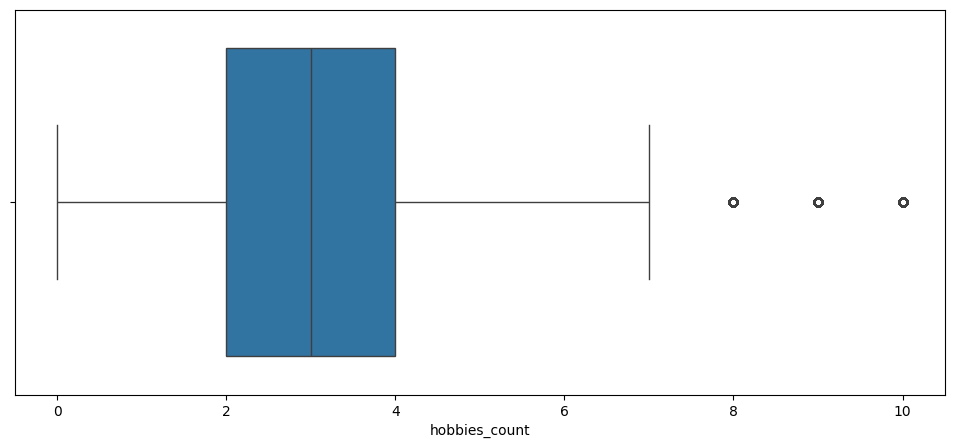

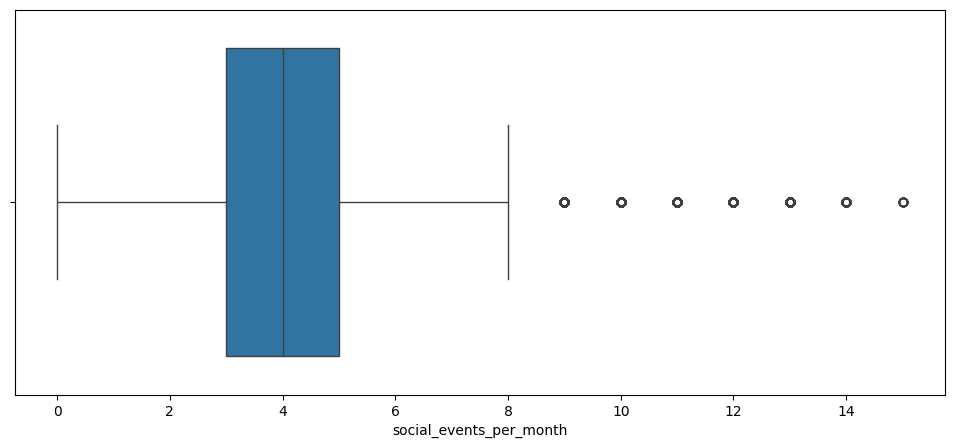

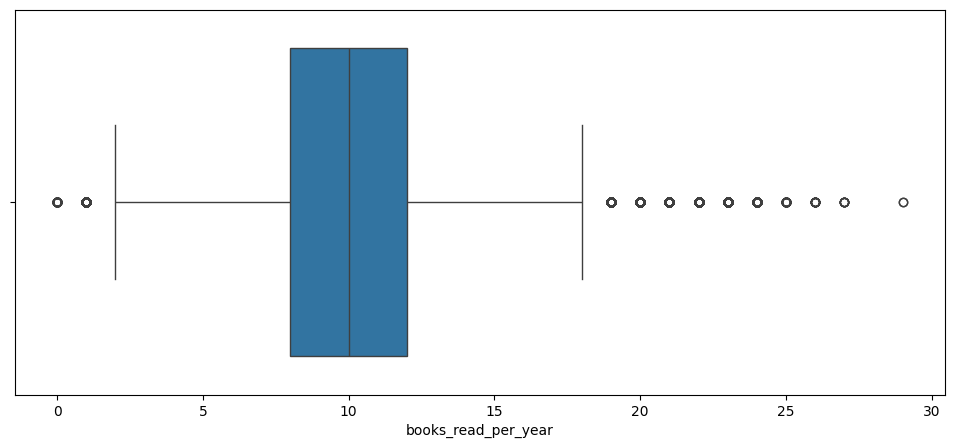

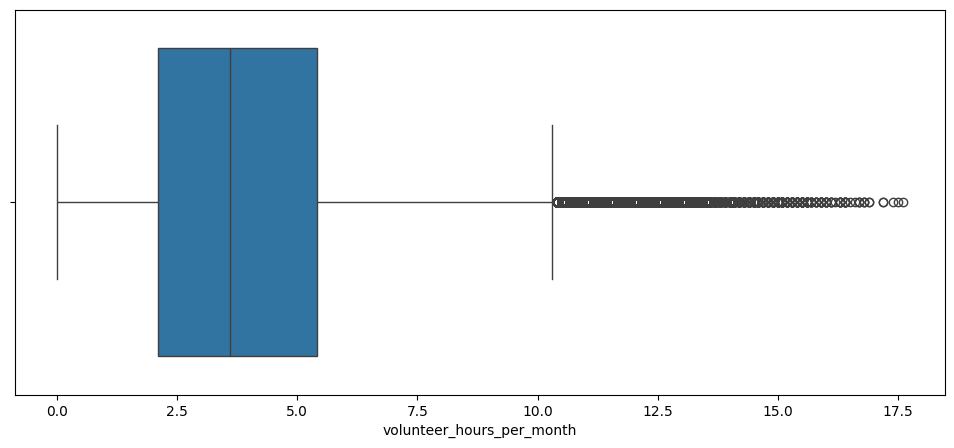

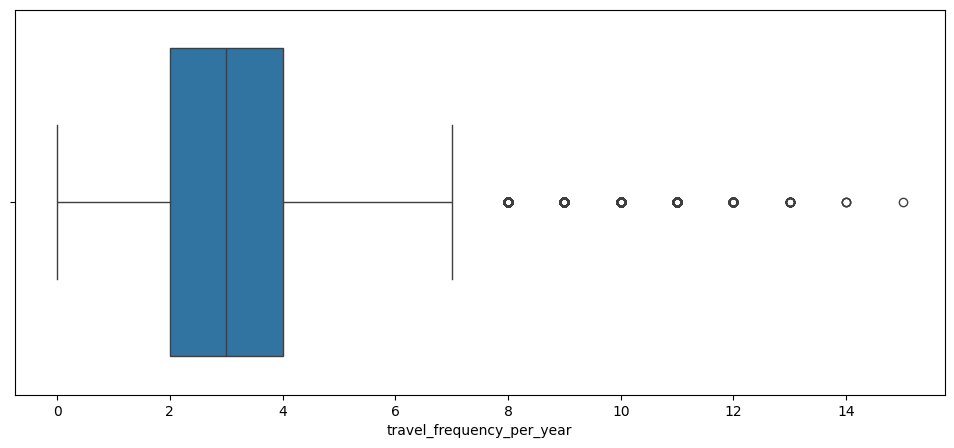

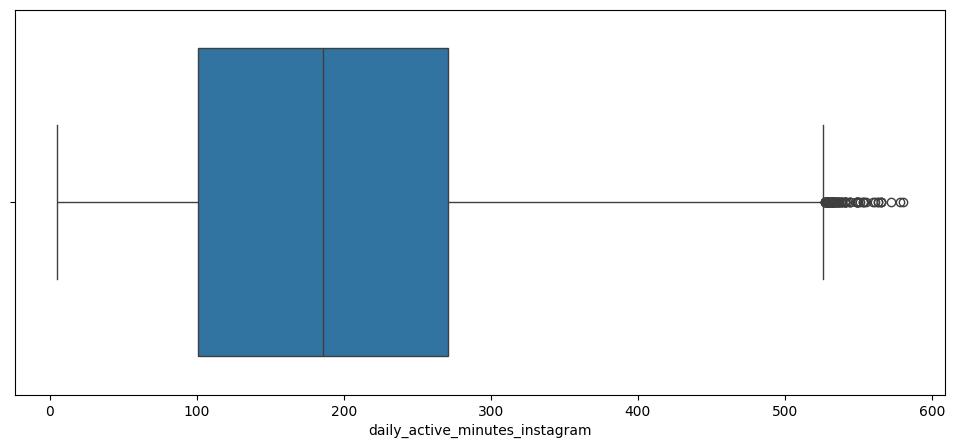

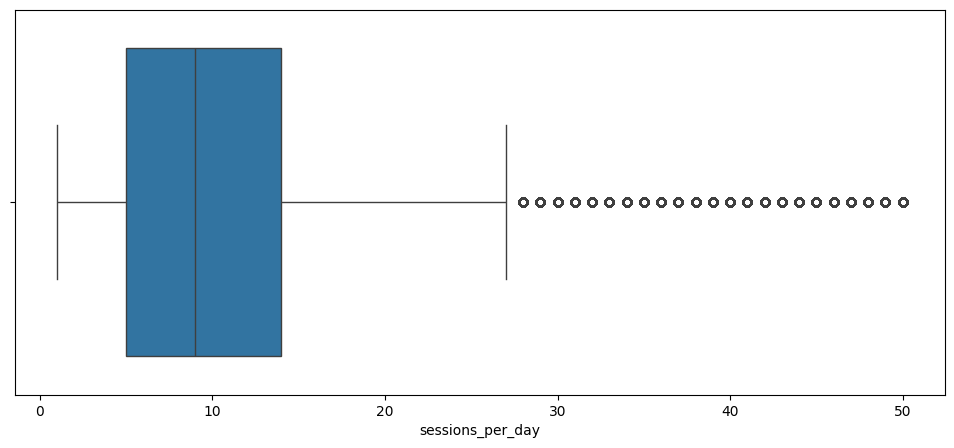

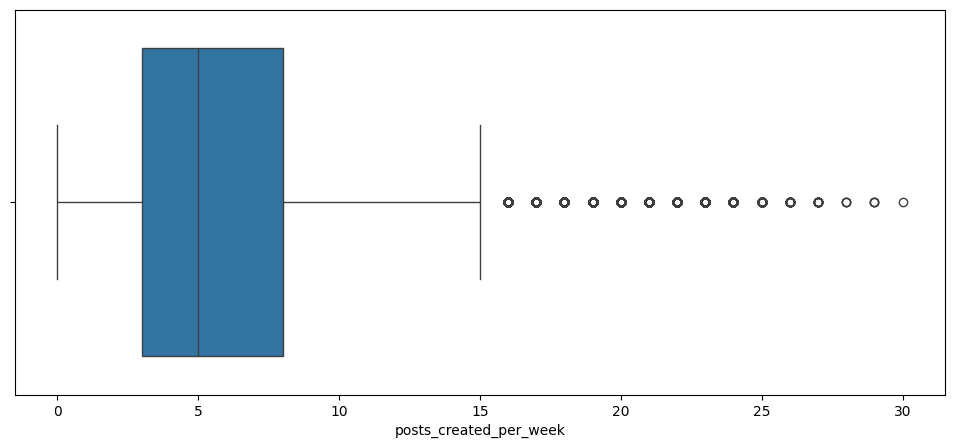

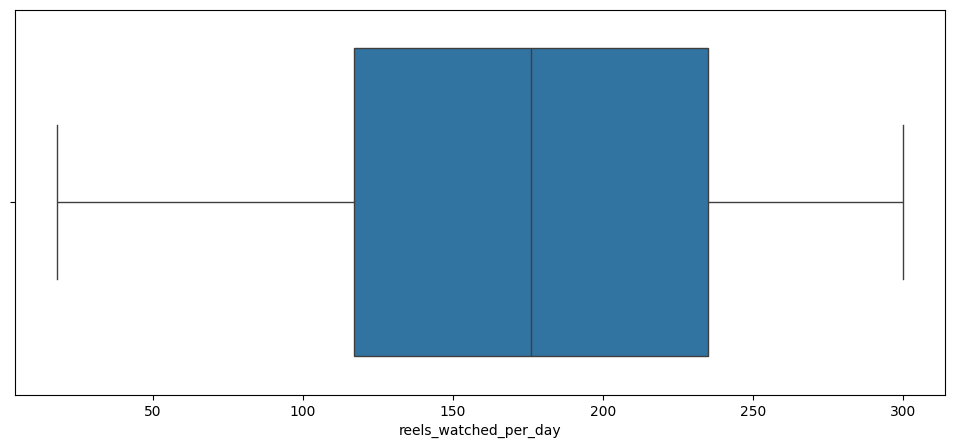

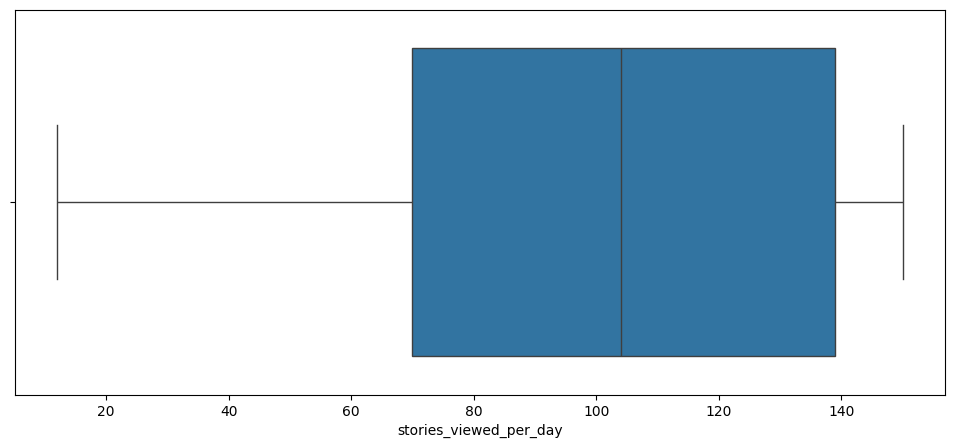

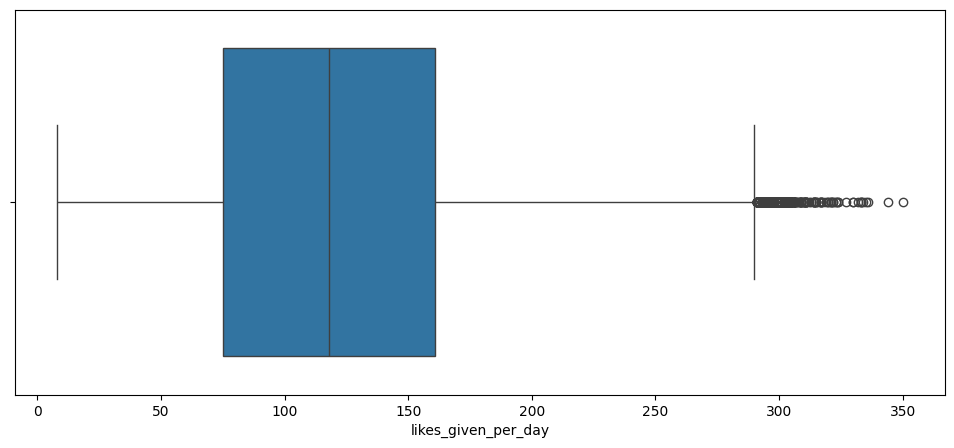

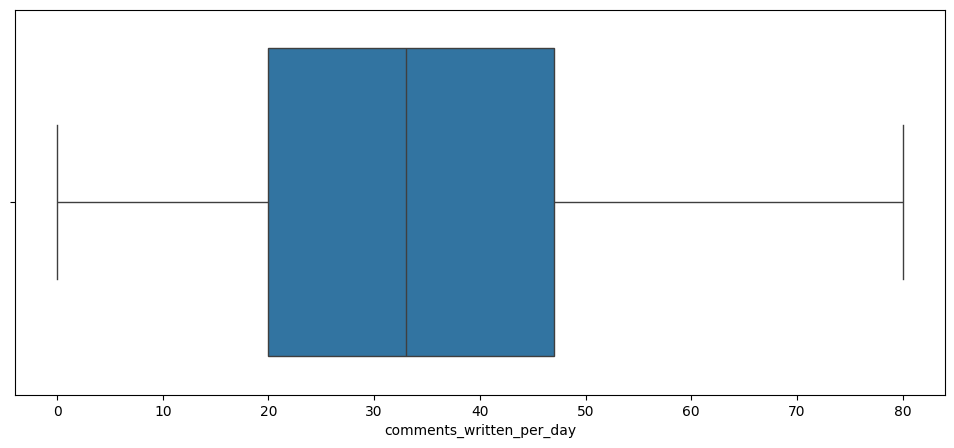

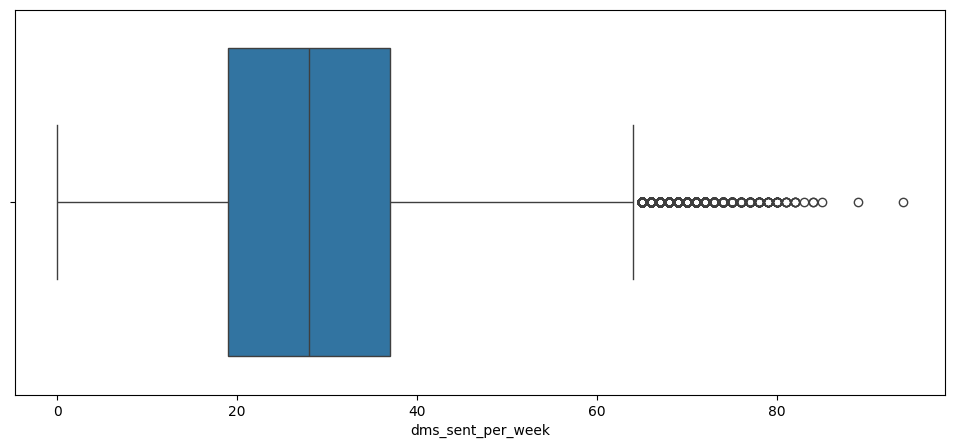

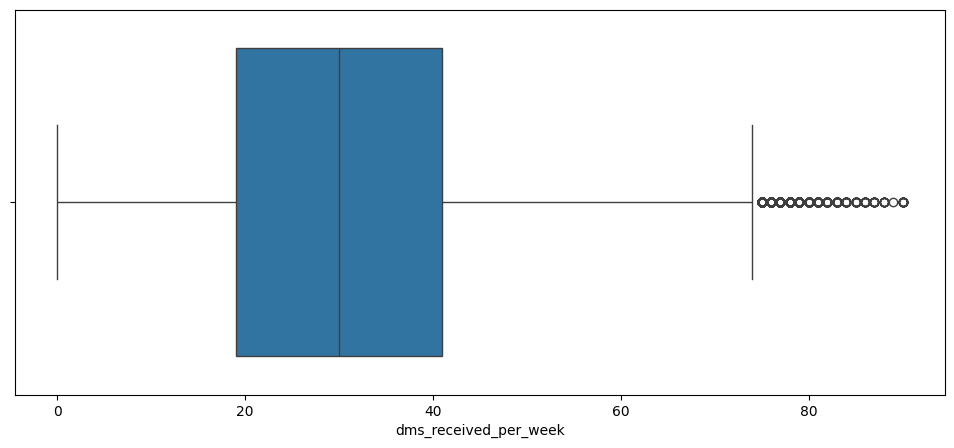

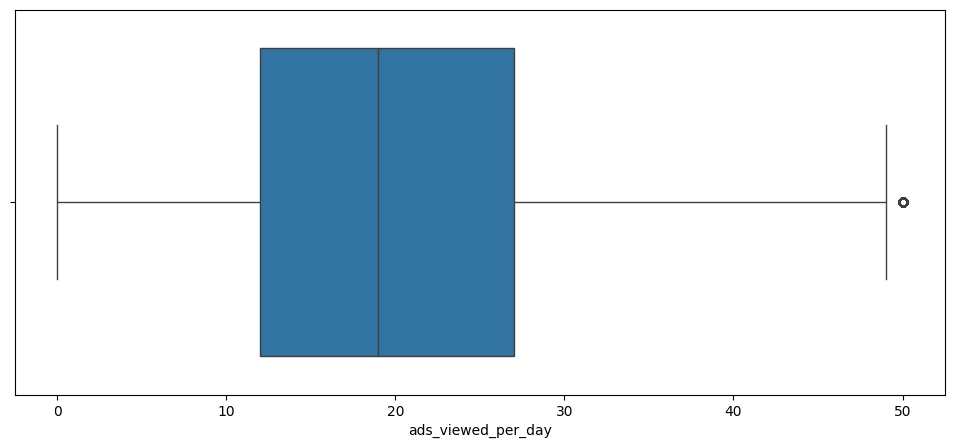

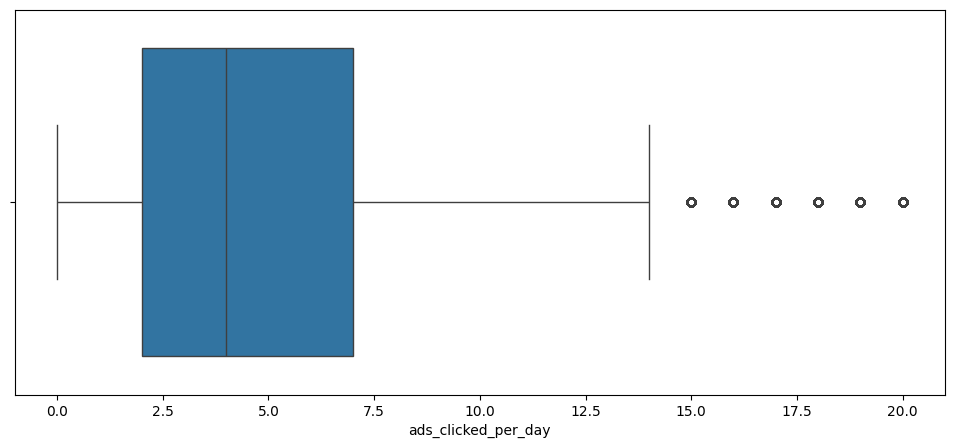

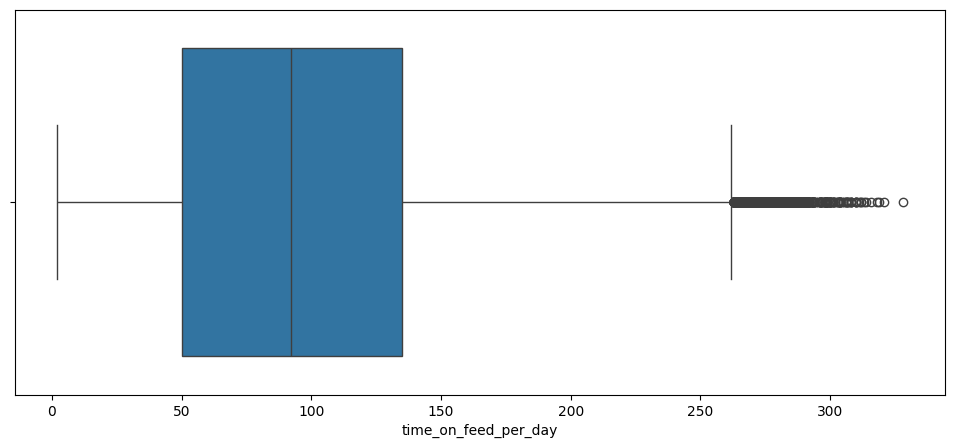

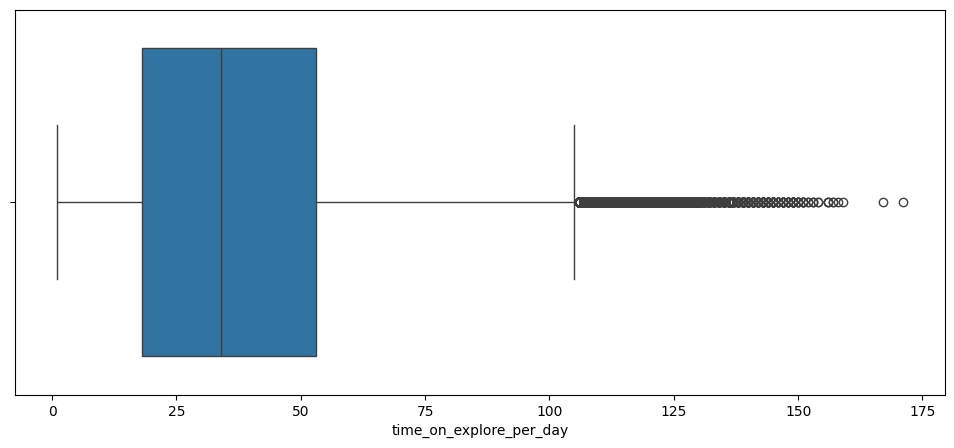

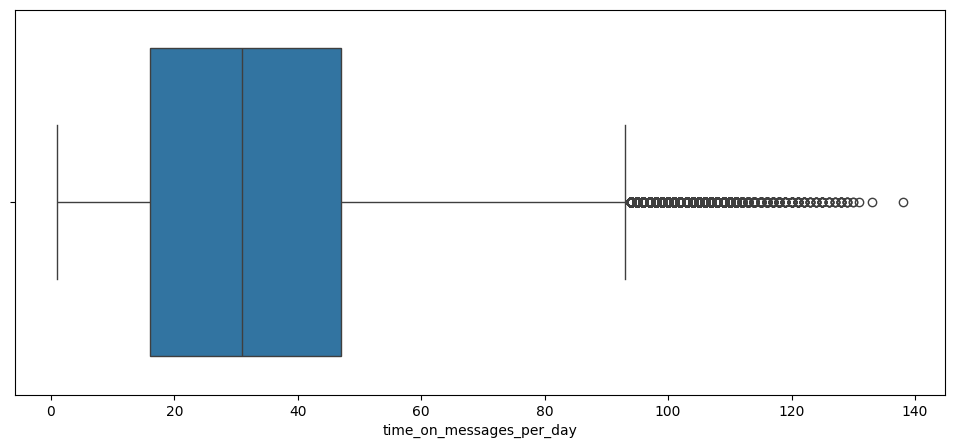

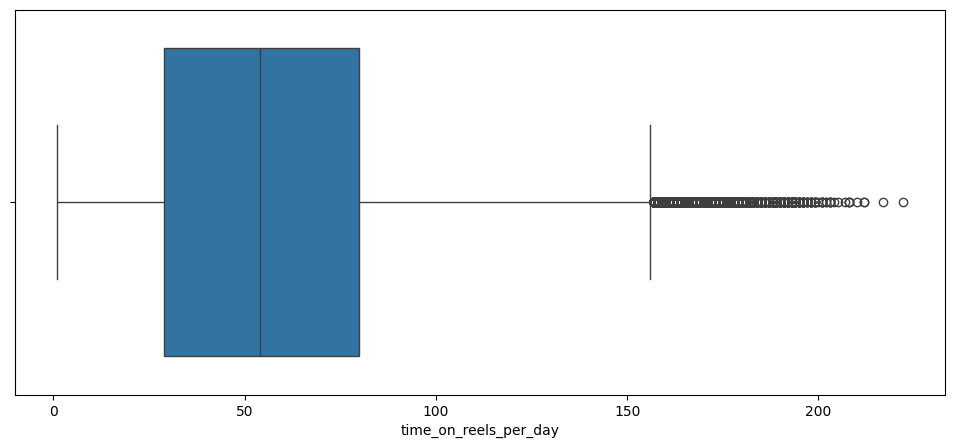

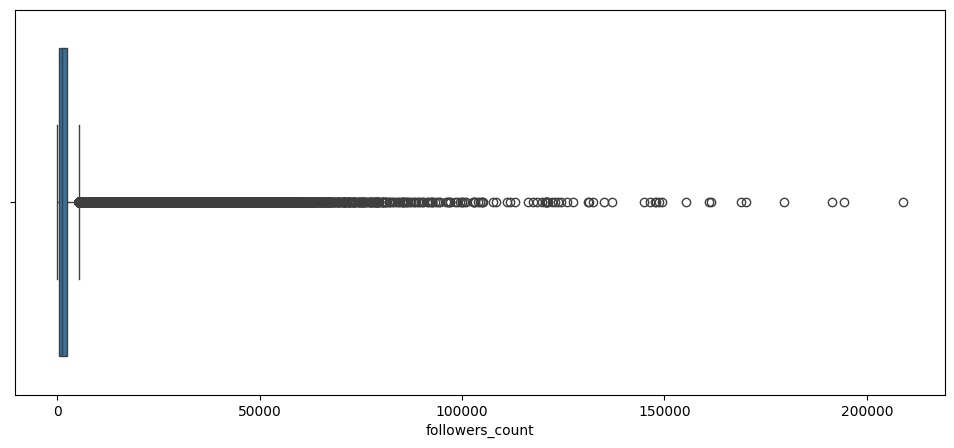

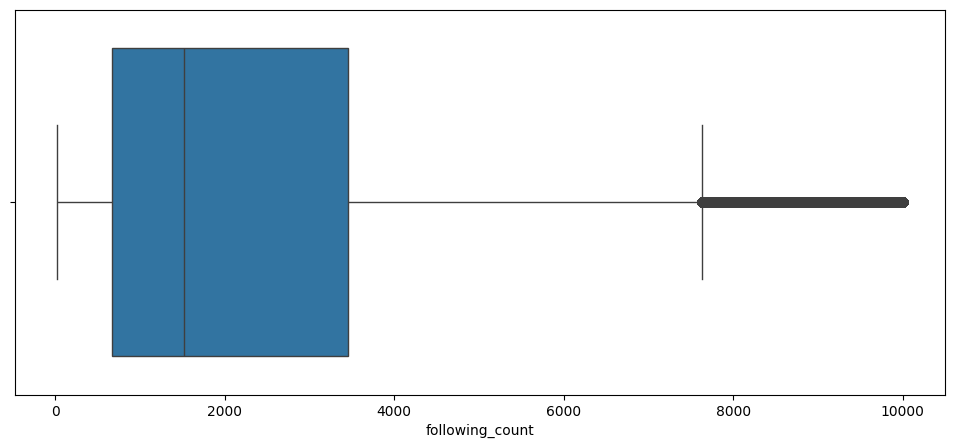

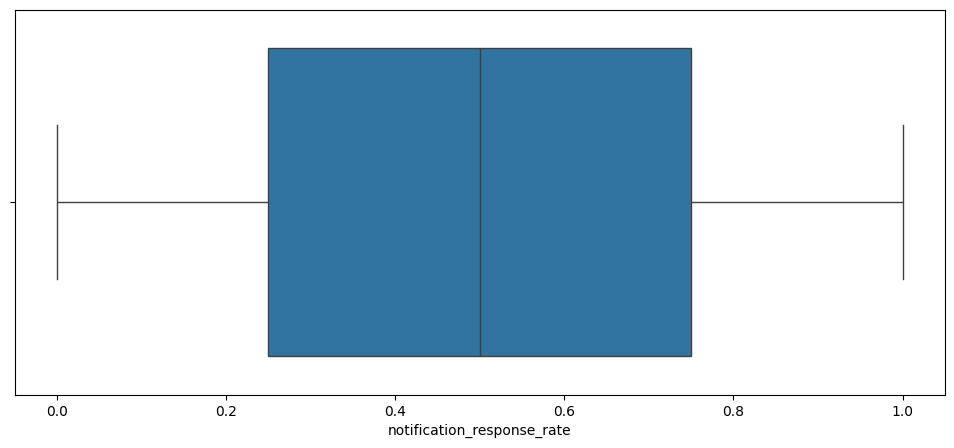

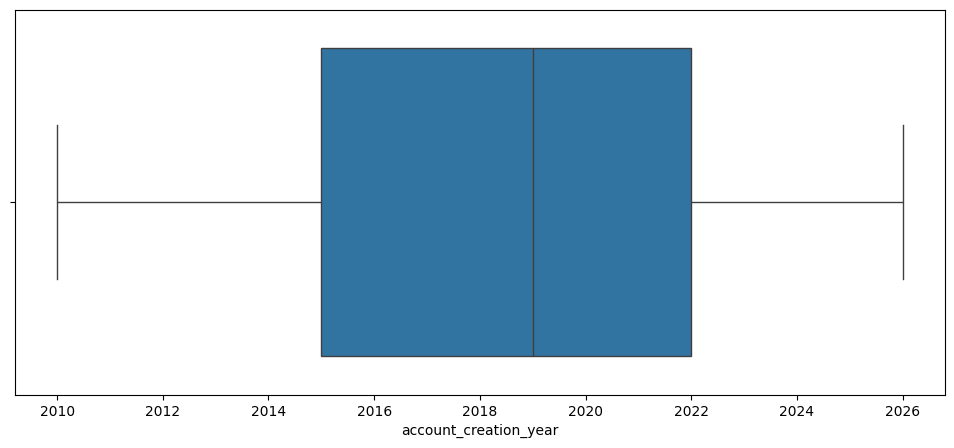

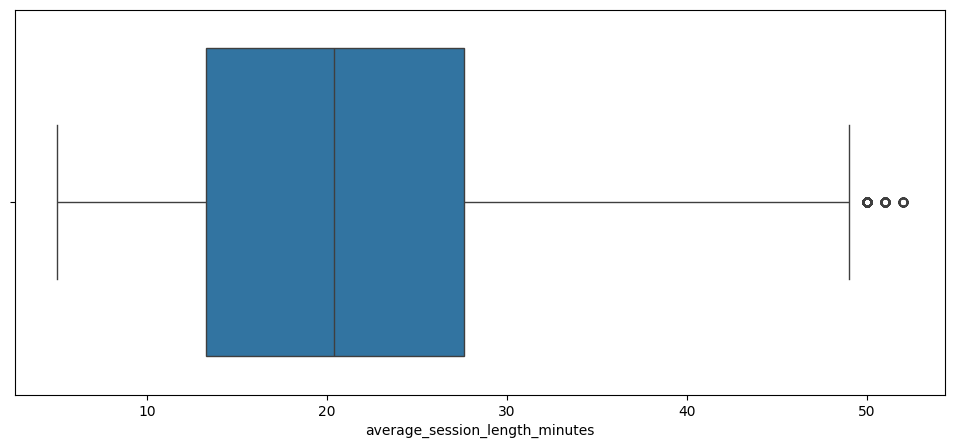

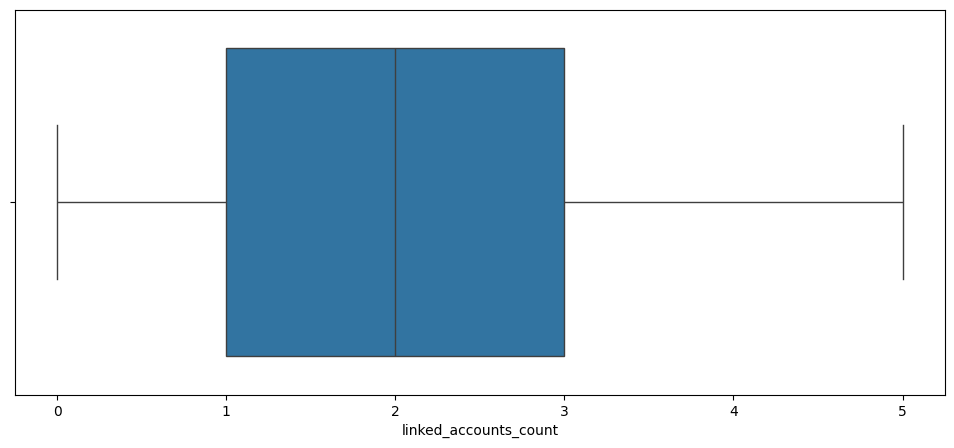

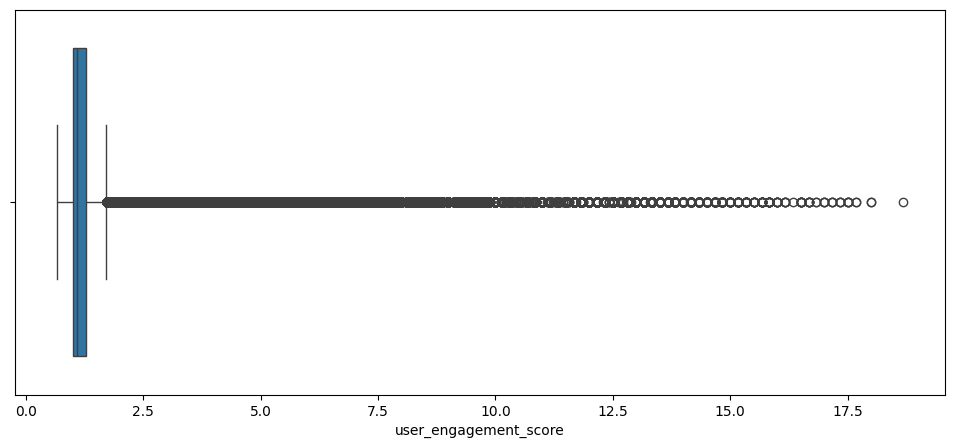

In [20]:
for column in df.select_dtypes('number').columns:
    boxplot(column)

In [21]:
df=df[df['sleep_hours_per_night']>3]
df=df[df['daily_active_minutes_instagram']<300]
df=df[df['likes_given_per_day']<200]

-----------------------------------------
### **Distribution of Variables**
--------------------------------------

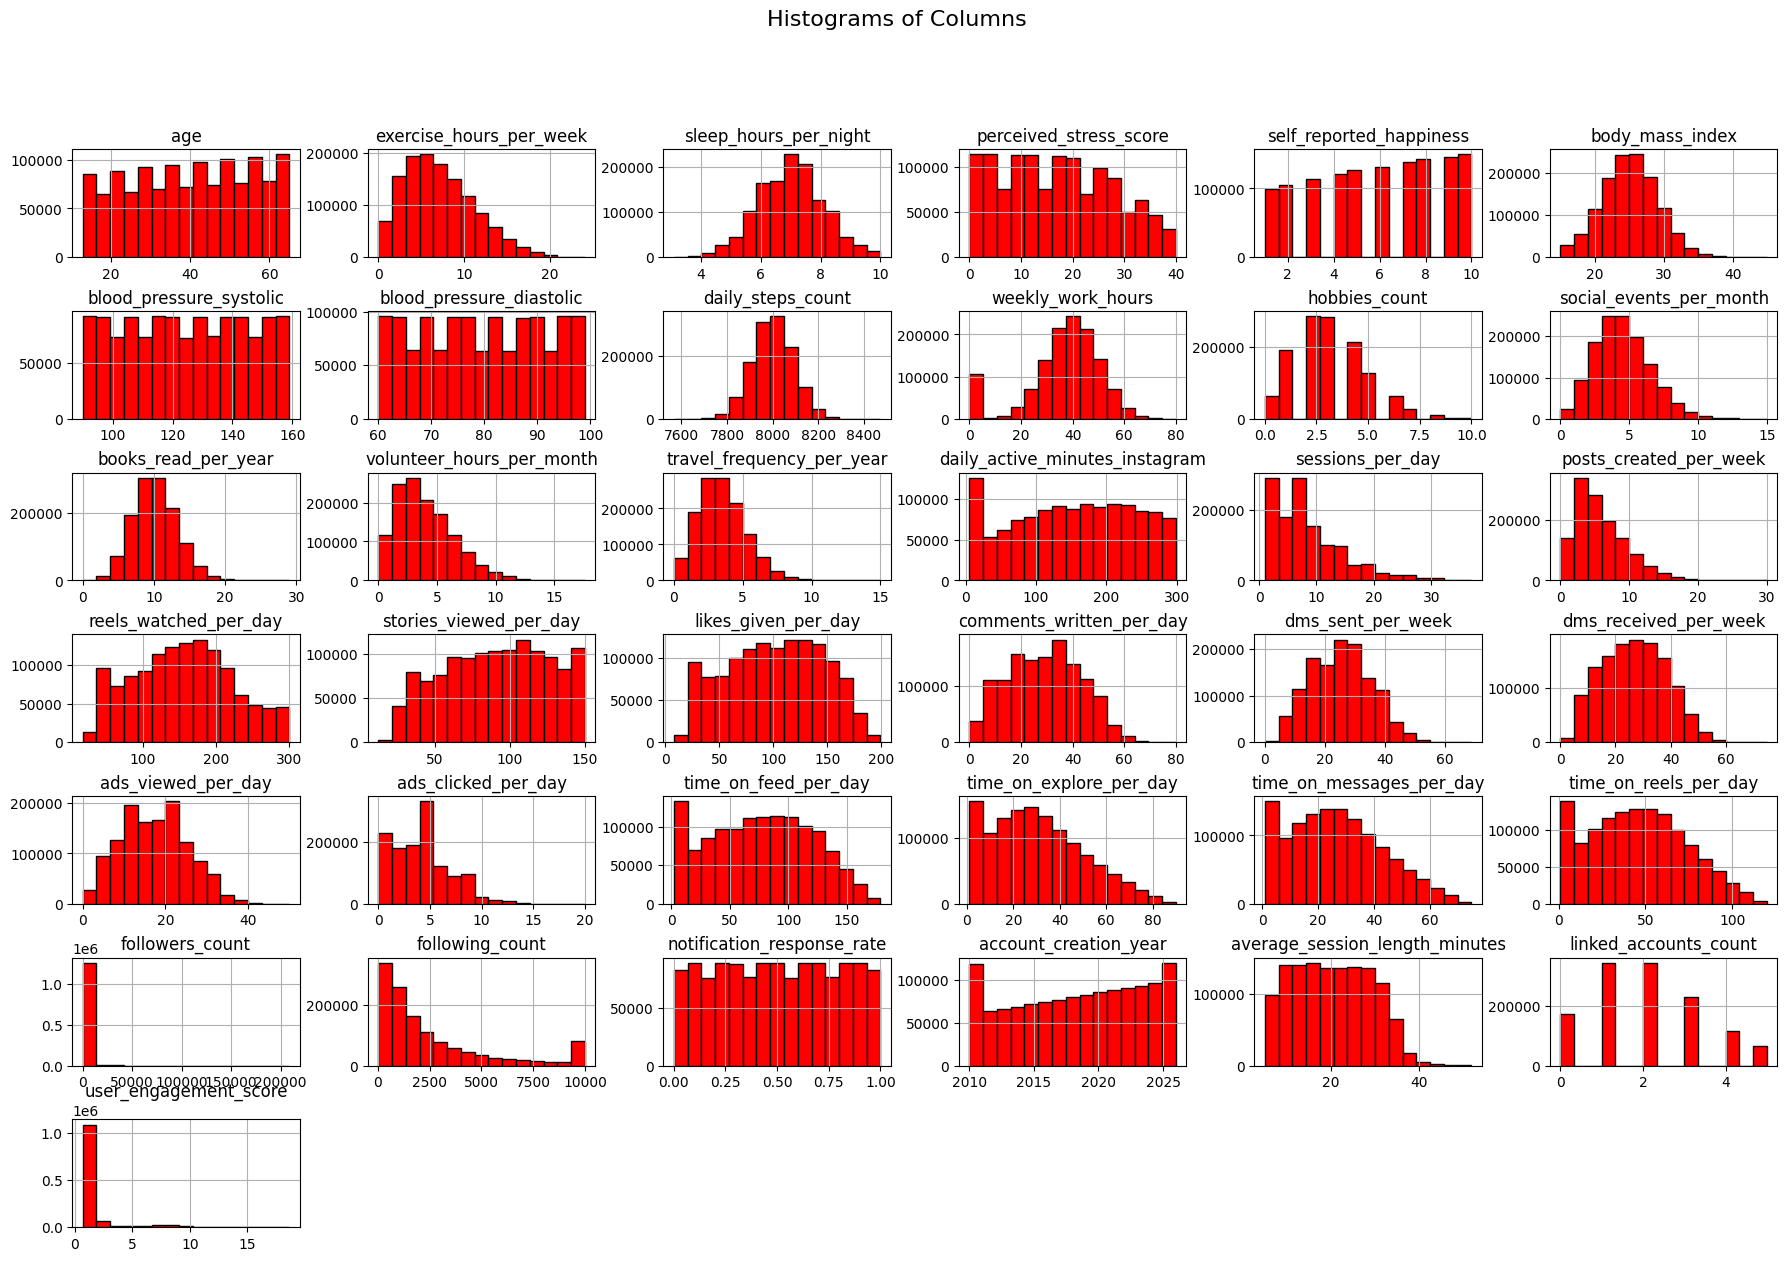

In [22]:
df.select_dtypes('number').hist(bins=15, figsize=(22, 14), color='red', edgecolor='black')

plt.suptitle('Histograms of Columns', fontsize=16)
plt.subplots_adjust(hspace=0.5)  
plt.show()

--------------------------------
### **Summary Statistical**
--------------------------------

In [23]:
def pie(data,col):
    data[col].value_counts().plot.pie(autopct='%0.2f%%')
    plt.xlabel(col)
    plt.show()

def countplot(data,col):
    plt.fig,ax= plt.subplots()
    plt.fig.set_size_inches(18,5)    
    sns.countplot(x=data[col], data=df)
    plt.xlabel(col)
    plt.xticks(rotation = 45)
    plt.show()

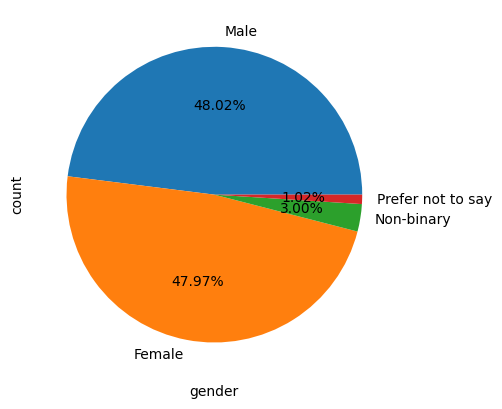

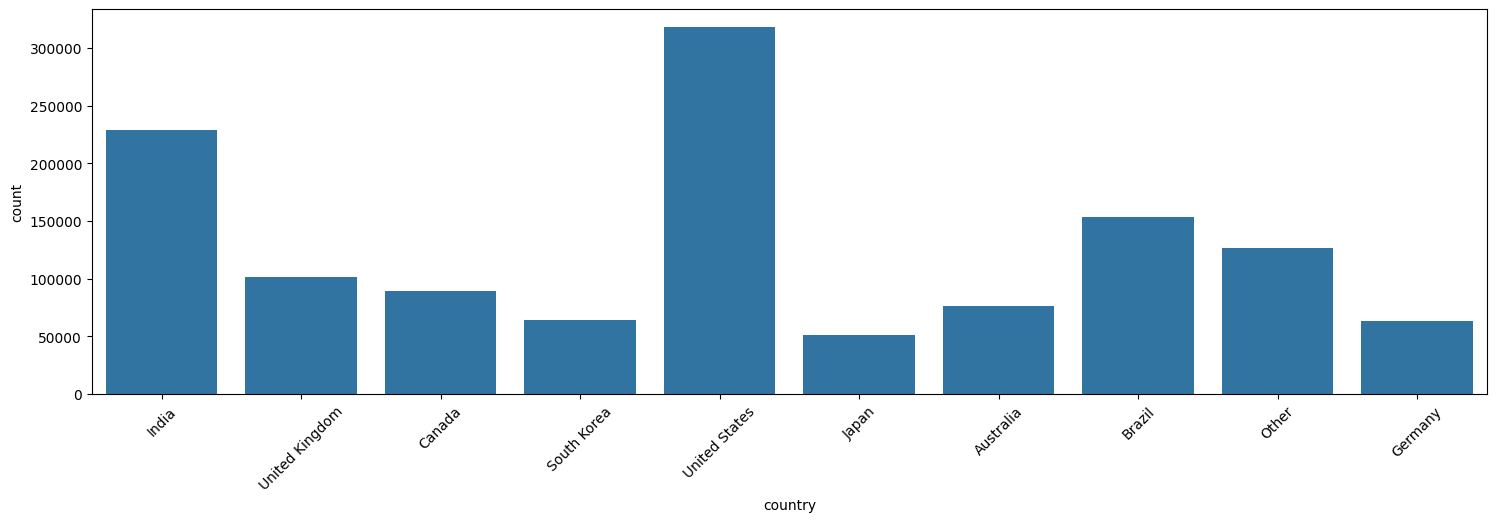

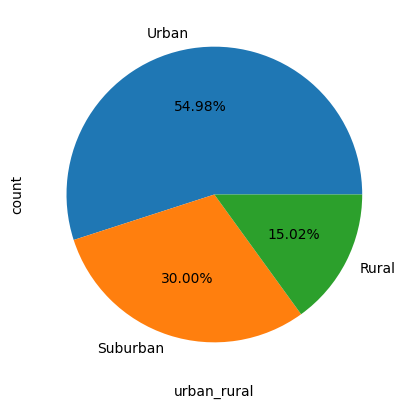

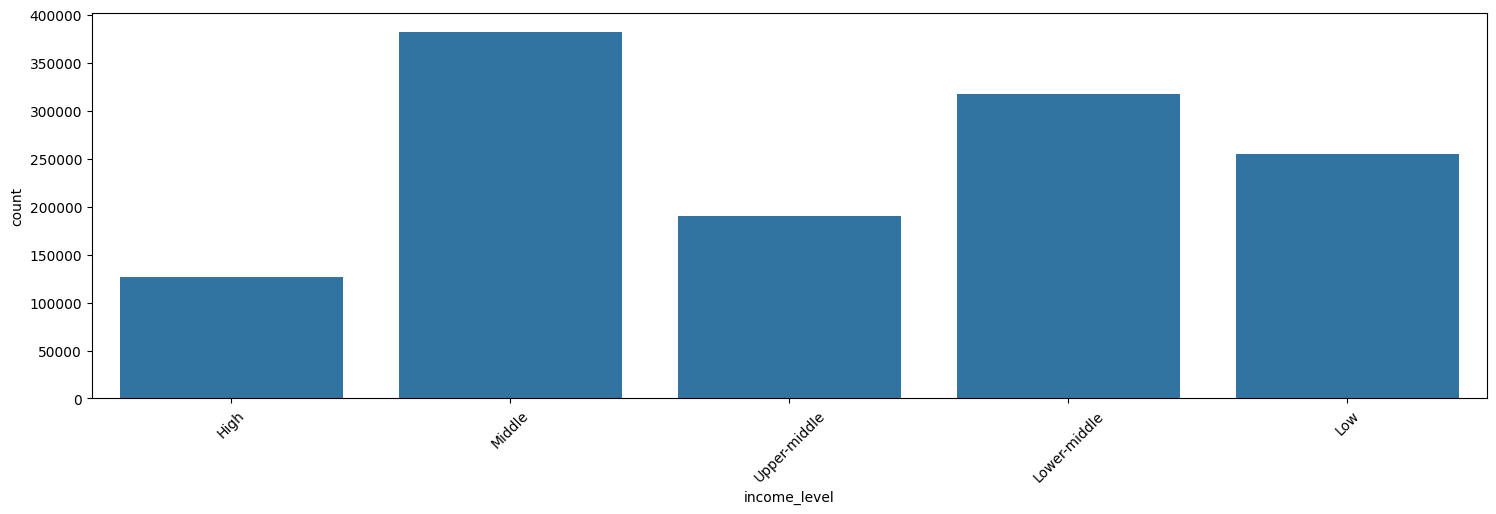

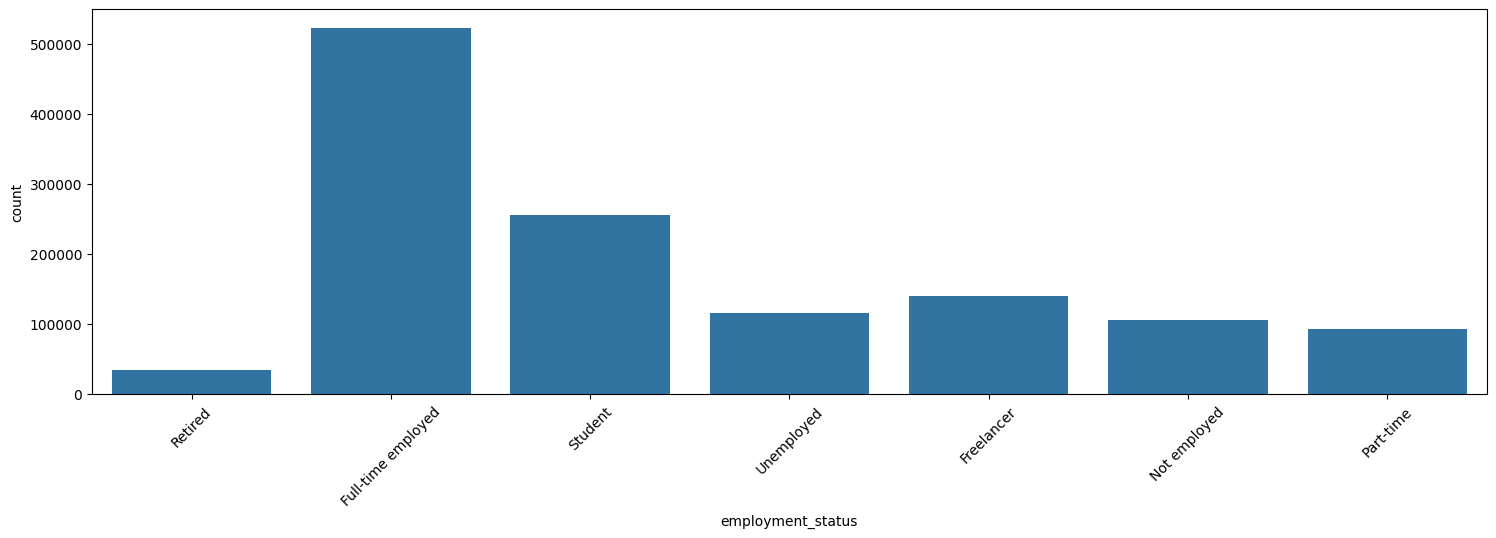

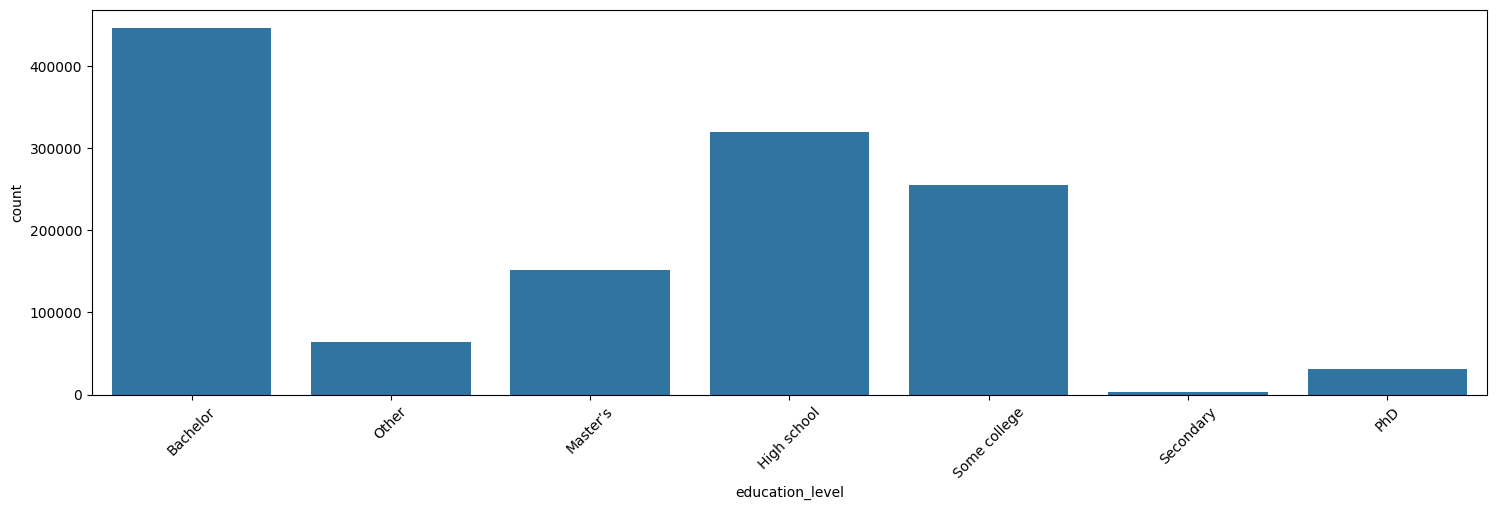

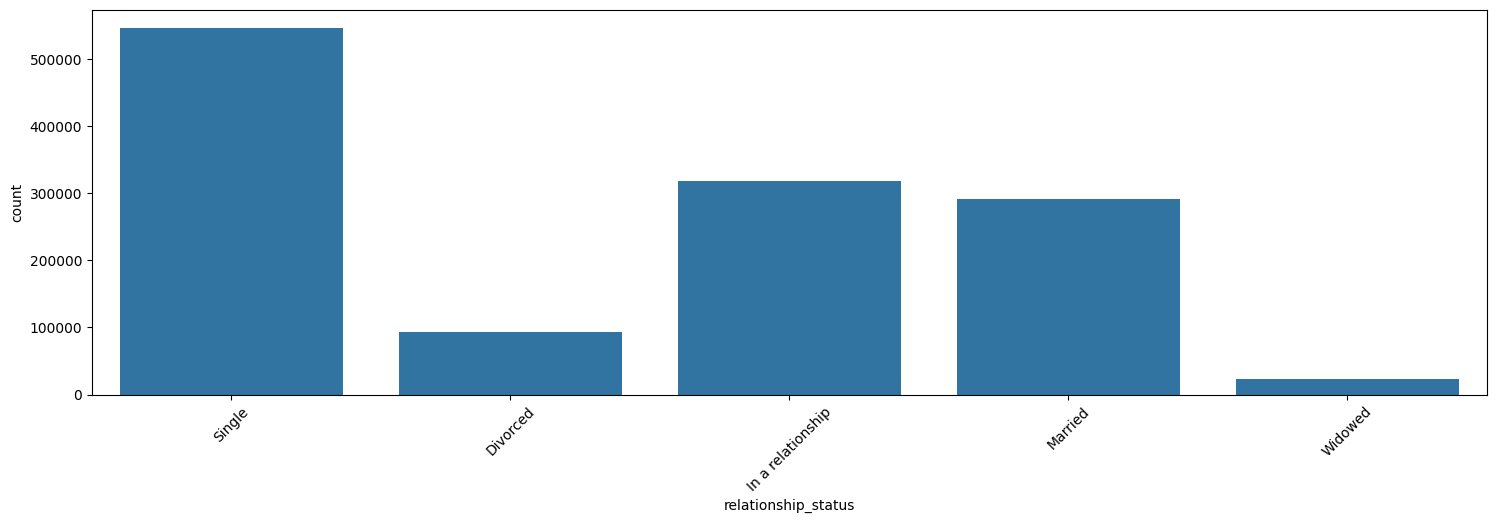

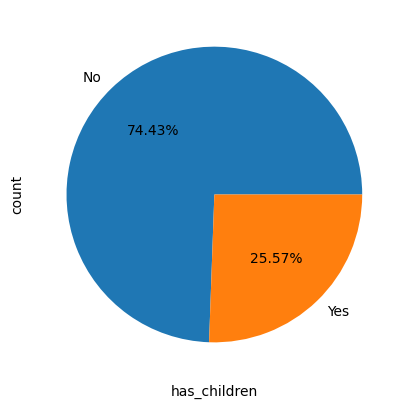

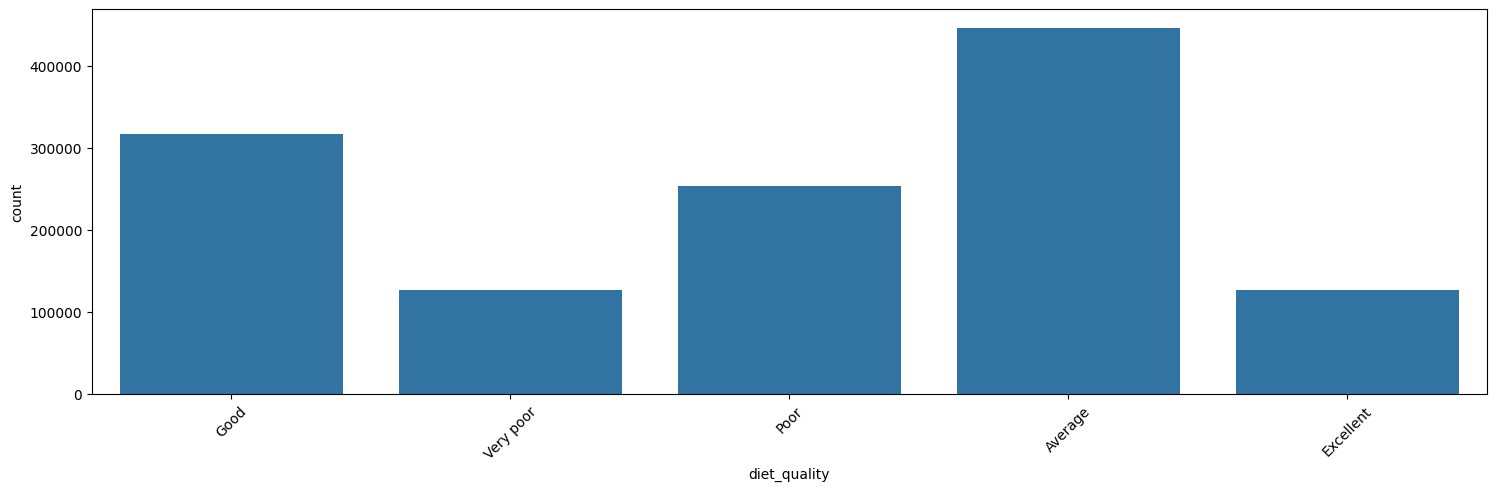

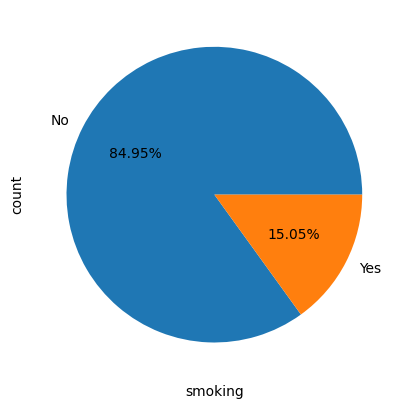

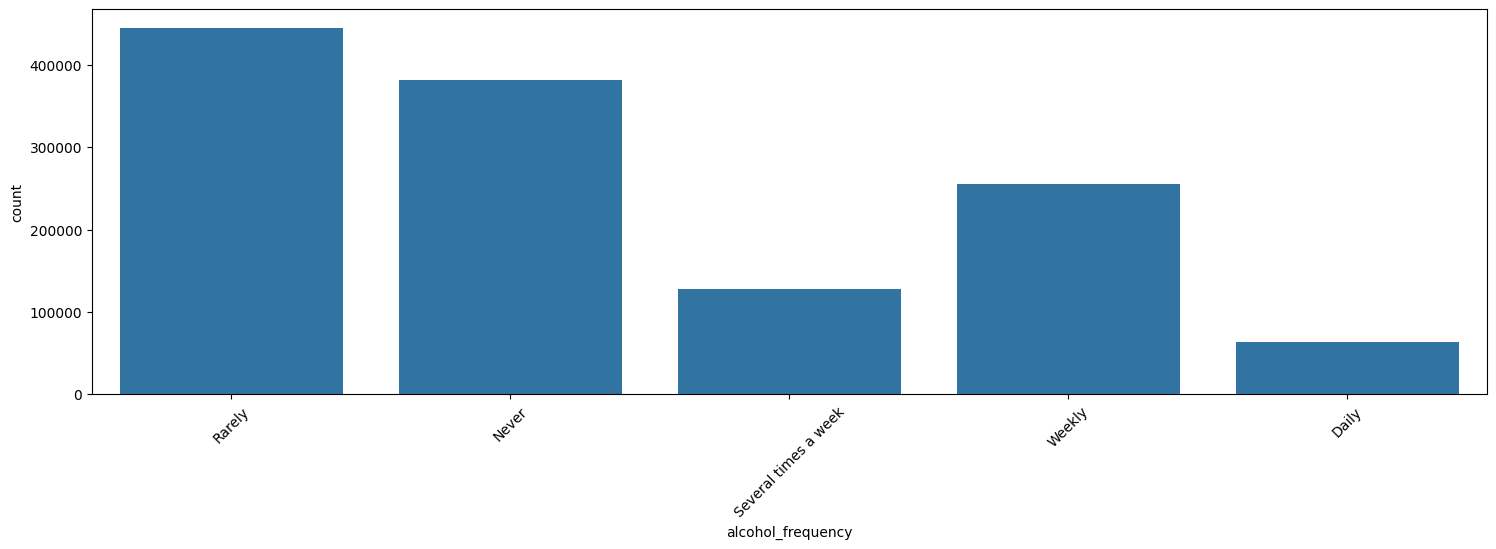

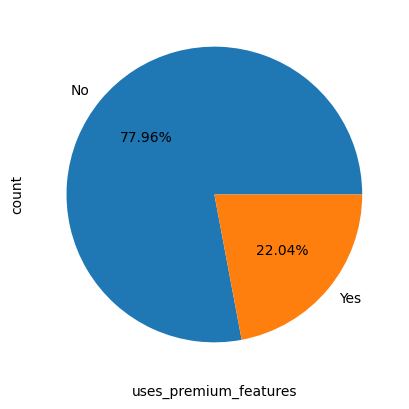

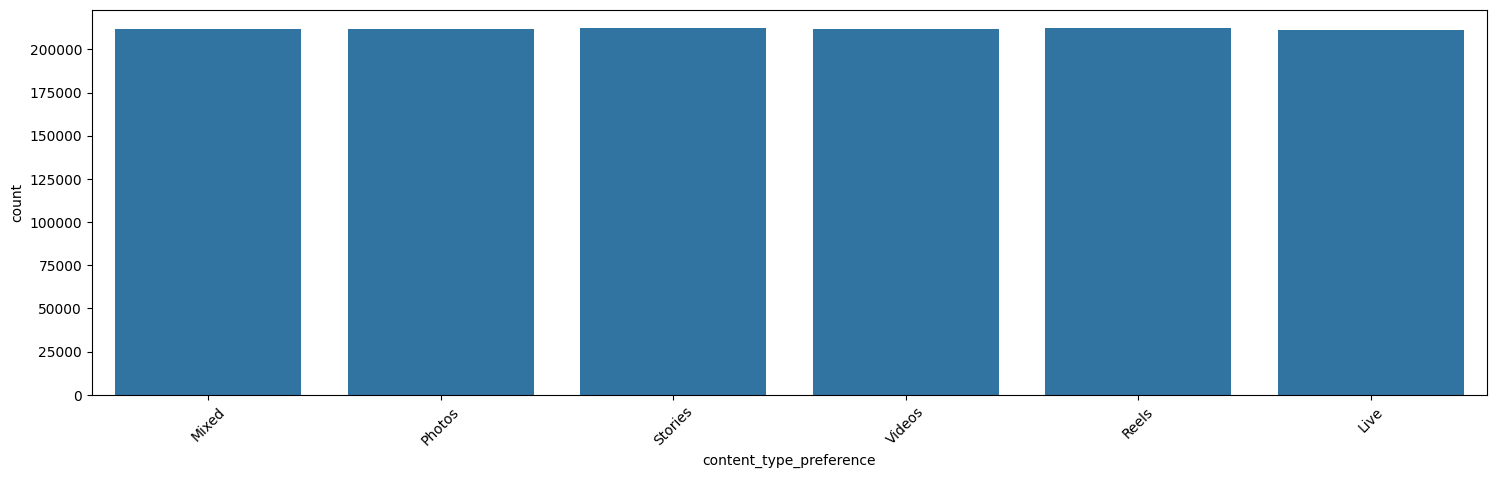

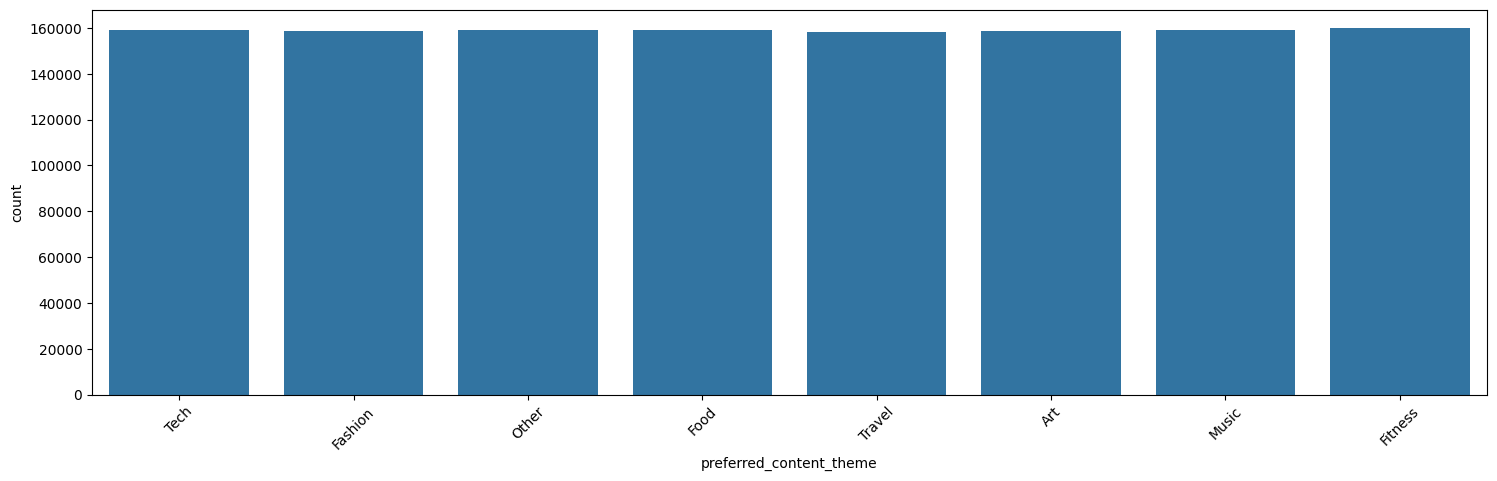

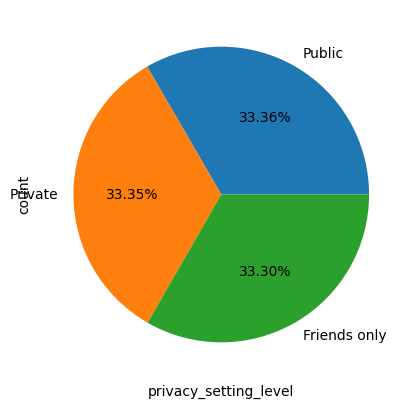

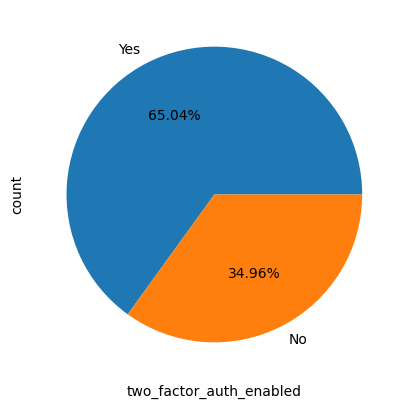

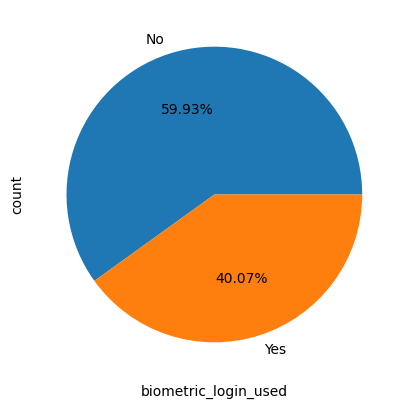

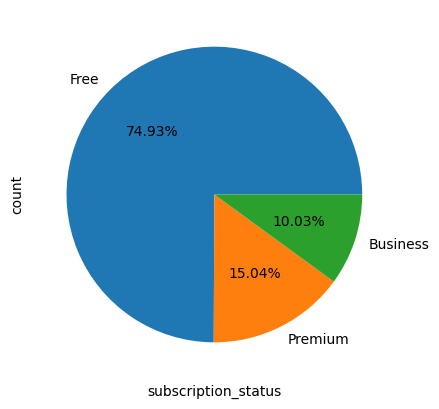

In [24]:
for col in df.select_dtypes('object').drop(['app_name','last_login_date'],axis=1).columns:
    if df.select_dtypes('object')[col].nunique() >=2 and df.select_dtypes('object')[col].nunique() <=4:
        pie(df.select_dtypes('object'),col)
    else :
        countplot(df.select_dtypes('object'),col)

-----------------------------
### **Checking Correlation between the features**
------------------------------

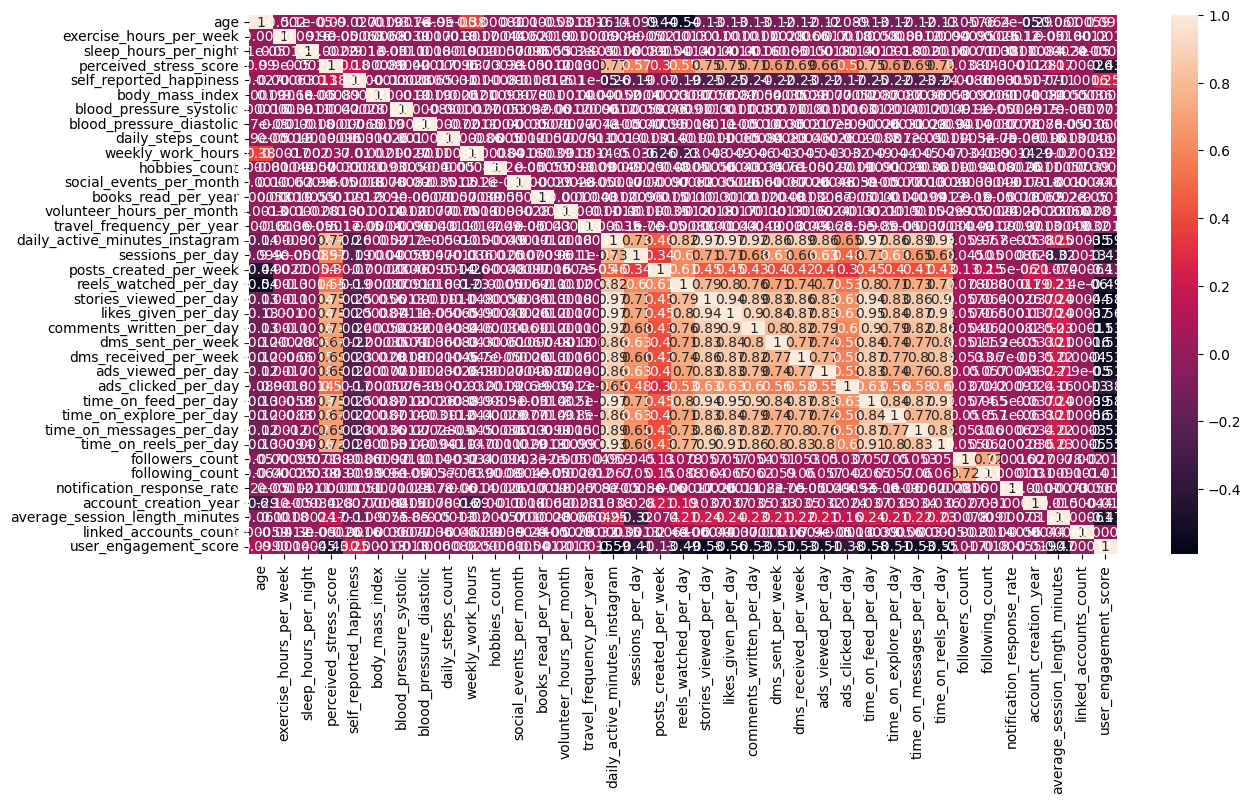

In [25]:
plt.figure(figsize=(14,	7))
sns.heatmap(df.select_dtypes('number').corr(), annot=True)
plt.show()

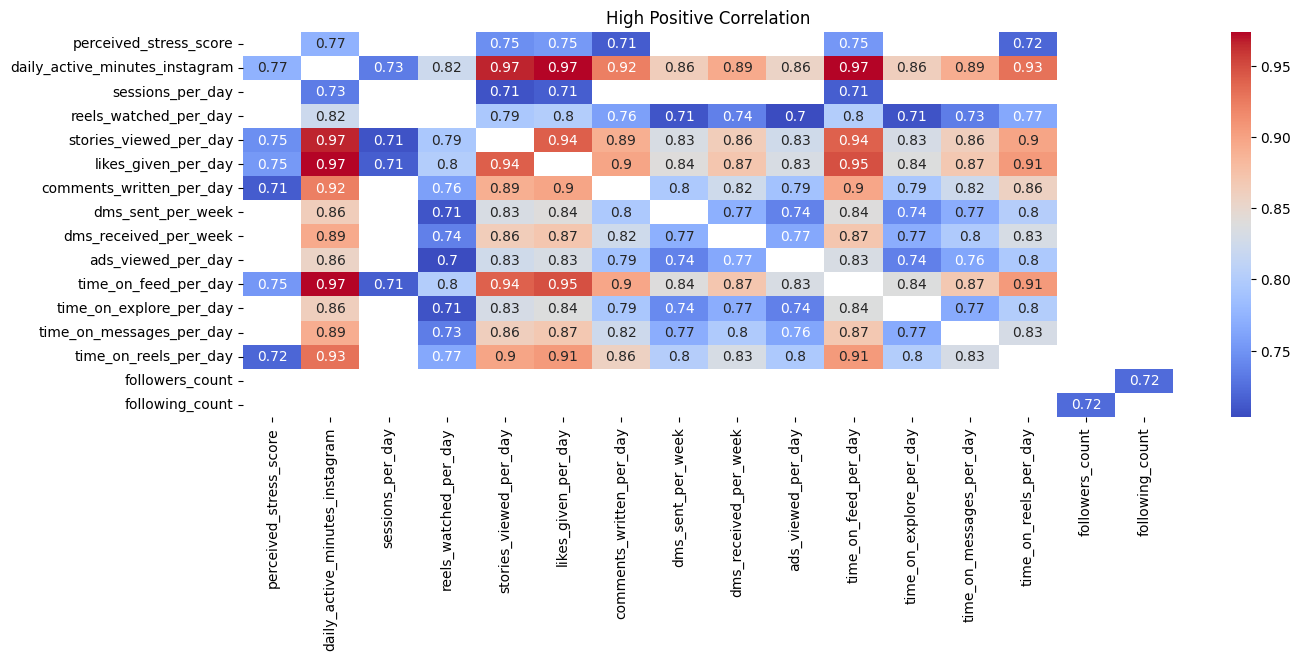

In [26]:
# function to extract high positive correlated columns
def get_high_corr(df, threshold):
     corr = df.select_dtypes('number').corr()
     high_corr = corr[(corr >= threshold) & (corr != 1.000)]
     high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
     return high_corr

# get high positive correlated columns
high_corr = get_high_corr(df, 0.7)

# plot high positive correlated columns
plt.figure(figsize=(15, 5))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Positive Correlation')
plt.show()

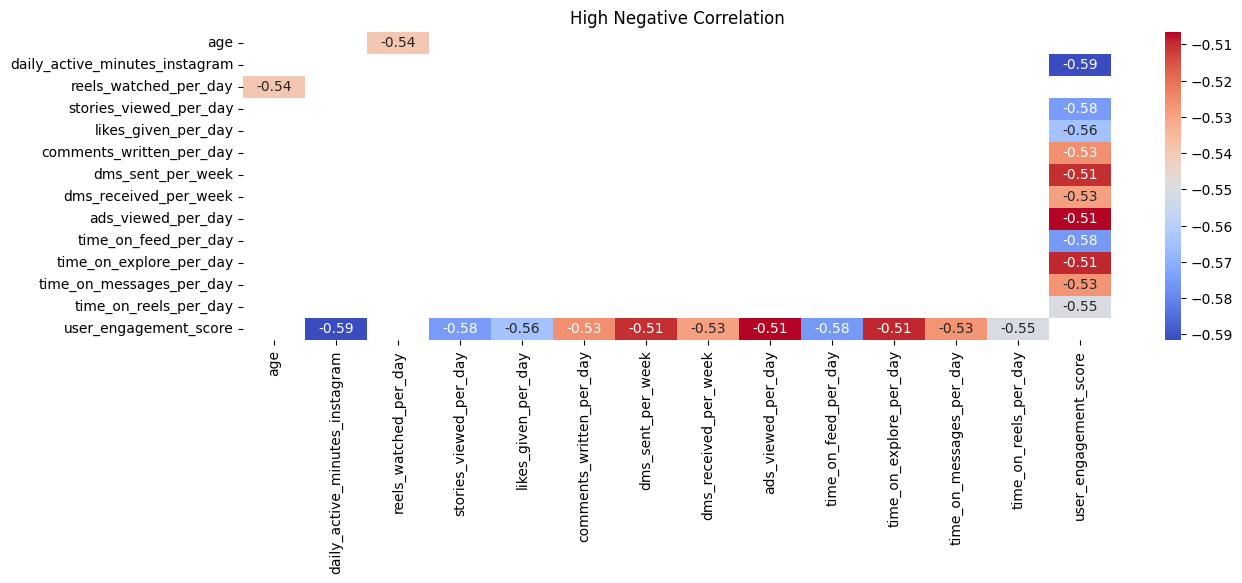

In [27]:
# function to extract high negative correlated columns
def get_high_corr(df, threshold):
     corr = df.select_dtypes('number').corr()
     high_corr = corr[(corr <= threshold) & (corr != 1.000)]
     high_corr = high_corr.dropna(how='all', axis=1).dropna(how='all', axis=0)
     return high_corr

# get high negative correlated columns
high_corr = get_high_corr(df, -0.5)

# plot high negative correlated columns
plt.figure(figsize=(14, 4))
plot = sns.heatmap(high_corr, annot=True, cmap='coolwarm')
plot.set_title('High Negative Correlation')
plt.show()

---------------------------------
---------------------------------
## **Feature Extraction**
---------------------------------

In [28]:
df['user_engagement_score'].describe()

count    1.271499e+06
mean     1.789460e+00
std      1.970026e+00
min      6.700000e-01
25%      1.040000e+00
50%      1.140000e+00
75%      1.380000e+00
max      1.867000e+01
Name: user_engagement_score, dtype: float64

In [29]:
def scoreSeg(a):
    if a <= 1:
        return 'Passive Users'
    elif a <= 1.10:
        return 'Casual Users'
    elif a <= 1.29:
        return 'Regular Users'
    else :
        return 'Power Users'

df['engagement_seg'] = df['user_engagement_score'].apply(lambda x: scoreSeg(x))

In [30]:
df['engagement_seg'].value_counts()

engagement_seg
Power Users      384089
Regular Users    345142
Casual Users     320935
Passive Users    221333
Name: count, dtype: int64

In [31]:
dtime = datetime.now()
# calcul age of cars
df['age_of_account']=dtime.year-df['account_creation_year']
df['age_of_account'].head()

0    11
1     8
2    15
3     7
4     9
Name: age_of_account, dtype: int64

In [32]:
def ageg(a):
    if a< 20:
        return 'Teen'
    elif a<30:
        return 'Young'
    elif a< 45:
        return 'Adult'
    elif a<60:
        return 'Middle'
    else :
        return 'Senior'

df['age_group'] = df['age'].apply(lambda x : ageg(x))

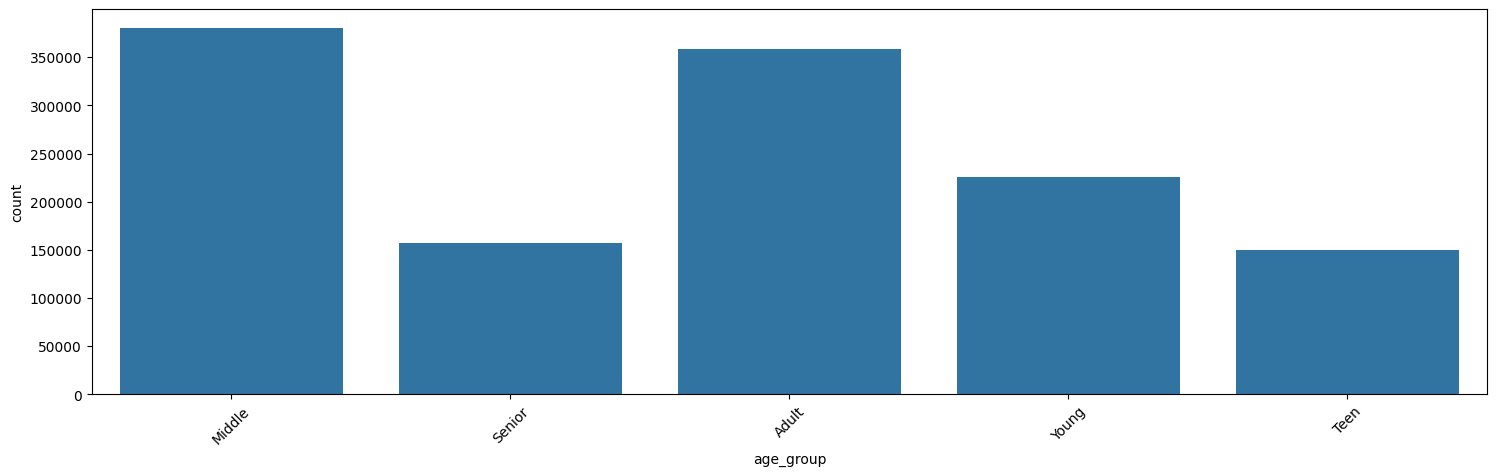

In [33]:
countplot(df,'age_group')

In [34]:
def reel(a):
    if a< 20:
        return 'Light Viewer'
    elif a<60:
        return 'Moderate Viewer'
    elif a< 100:
        return 'Heavy Viewer'
    else :
        return 'Binge Watcher'

df['reels_watch_segment'] = df['reels_watched_per_day'].apply(lambda x : reel(x))

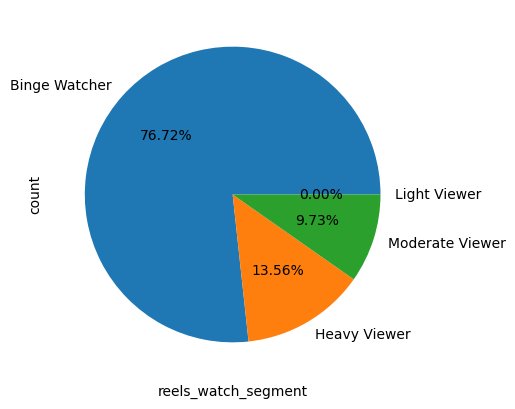

In [35]:
pie(df,'reels_watch_segment')

In [36]:
def feed(a):
    if a< 20:
        return 'Casual'
    elif a<50:
        return 'Regular'
    elif a< 80:
        return 'Active'
    else :
        return 'Power User'

df['usage_level'] = df['time_on_feed_per_day'].apply(lambda x : feed(x))

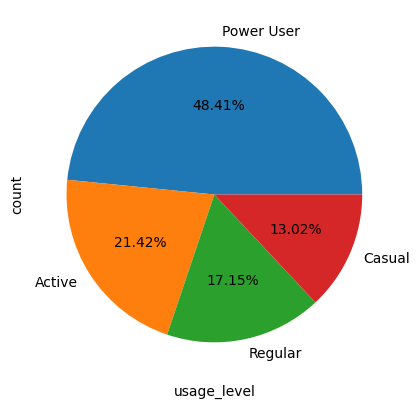

In [37]:
pie(df,'usage_level')

In [38]:
# df.to_csv('filename.csv',index=False)

---------------------------
---------------------------
## **Selected features for classification model**
---------------------------

In [39]:
classif_df = df[[
    'gender',
    'country',
    'urban_rural',
    'income_level',
    'employment_status',
    'education_level',
    'relationship_status',
    'has_children',
    'exercise_hours_per_week',
    'sleep_hours_per_night',
    'diet_quality',
    'smoking',
    'alcohol_frequency',
    'self_reported_happiness',
    'body_mass_index',
    'blood_pressure_systolic',
    'blood_pressure_diastolic',
    'daily_steps_count',
    'weekly_work_hours',
    'hobbies_count',
    'social_events_per_month',
    'books_read_per_year',
    'volunteer_hours_per_month',
    'travel_frequency_per_year',
    'notification_response_rate',
    'linked_accounts_count',
    'privacy_setting_level',
    'two_factor_auth_enabled',
    'biometric_login_used',
    'subscription_status',
    'uses_premium_features',
    'daily_active_minutes_instagram',
    'sessions_per_day',
    'posts_created_per_week',
    'stories_viewed_per_day',
    'likes_given_per_day',
    'comments_written_per_day',
    'dms_sent_per_week',
    'dms_received_per_week',
    'ads_viewed_per_day',
    'ads_clicked_per_day',
    'time_on_explore_per_day',
    'time_on_messages_per_day',
    'time_on_reels_per_day',
    'average_session_length_minutes',
    'content_type_preference',
    'preferred_content_theme',
    'perceived_stress_score',
    'age_of_account',
    'engagement_seg',
    'age_group',
    'reels_watch_segment',
    'usage_level'
]]

In [40]:
classif_df.select_dtypes('object').head()

,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,diet_quality,smoking,...,two_factor_auth_enabled,biometric_login_used,subscription_status,uses_premium_features,content_type_preference,preferred_content_theme,engagement_seg,age_group,reels_watch_segment,usage_level
0,Female,India,Rural,High,Retired,Bachelor,Single,No,Good,No,...,Yes,No,Free,No,Mixed,Tech,Power Users,Middle,Moderate Viewer,Casual
1,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,No,Very poor,No,...,No,No,Free,No,Photos,Fashion,Power Users,Senior,Heavy Viewer,Regular
2,Female,Canada,Urban,Middle,Student,Bachelor,In a relationship,No,Good,No,...,Yes,Yes,Free,No,Mixed,Other,Power Users,Adult,Moderate Viewer,Casual
3,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,No,Poor,Yes,...,No,No,Free,No,Stories,Tech,Passive Users,Young,Binge Watcher,Power User
4,Male,India,Urban,Upper-middle,Full-time employed,Bachelor,Single,No,Average,No,...,Yes,No,Free,Yes,Videos,Food,Casual Users,Middle,Binge Watcher,Active


In [41]:
classif_df.select_dtypes('number').head()

,exercise_hours_per_week,sleep_hours_per_night,self_reported_happiness,body_mass_index,blood_pressure_systolic,blood_pressure_diastolic,daily_steps_count,weekly_work_hours,hobbies_count,social_events_per_month,...,dms_sent_per_week,dms_received_per_week,ads_viewed_per_day,ads_clicked_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,average_session_length_minutes,perceived_stress_score,age_of_account
0,7.2,7.7,8,20.8,148,86,8107,49.9,3,4,...,12,12,4,1,1,1,2,5.0,3,11
1,10.9,8.6,1,23.5,133,84,8059,15.6,0,5,...,18,10,11,1,19,16,19,14.8,1,8
2,5.0,6.7,10,28.6,135,88,7872,31.8,4,5,...,12,13,4,0,1,1,1,5.0,4,15
3,10.6,6.5,1,22.5,105,73,7801,43.4,2,3,...,31,32,33,3,64,52,64,25.9,18,7
4,7.7,6.8,1,28.1,146,90,8005,50.2,2,2,...,29,37,20,5,55,22,55,13.1,19,9


In [42]:
classif_df = classif_df[:1000200]

In [43]:
data_for_test = classif_df[1000000:]

In [44]:
data_for_test.to_excel('data_for_test.xlsx',index=False)

In [45]:
classif_df = classif_df[:1000000]

In [46]:
# dnn_df = classif_df.copy()

------------------------------------
### **Pipeline**
------------------------------------

In [47]:
d = {'Passive Users': 0, 'Casual Users': 1, 'Regular Users' : 2, 'Power Users' : 3}
classif_df['engagement_seg'] = classif_df['engagement_seg'].map(d)

In [48]:
classif_df['engagement_seg'].value_counts()

engagement_seg
3    302033
2    271203
1    252805
0    173959
Name: count, dtype: int64

In [49]:
ordered_cats = [
    ['Male','Female','Non-binary','Prefer not to say'],
    ['India', 'United Kingdom', 'Canada', 'South Korea', 'United States', 'Japan', 'Australia', 'Brazil', 'Other','Germany'],
    ['Rural', 'Urban', 'Suburban'],
    ['High', 'Upper-middle', 'Middle','Lower-middle', 'Low'],
    ['Retired', 'Full-time employed', 'Student', 'Unemployed', 'Freelancer', 'Not employed', 'Part-time'],
    ['Bachelor', 'Other', 'Master’s', 'High school', 'Some college','Secondary', 'PhD'],
    ['Single', 'Divorced', 'In a relationship', 'Married', 'Widowed'],
    ['No', 'Yes'],
    ['Very poor','Poor','Average','Good','Excellent'],
    ['No', 'Yes'],
    ['Never','Rarely','Several times a week','Weekly','Daily'],
    ['Private', 'Public', 'Friends only'],
    ['No', 'Yes'],
    ['No', 'Yes'],
    ['Free', 'Premium', 'Business'],
    ['No', 'Yes'],
    ['Stories','Mixed','Reels','Live','Videos','Photos'],
    ['Fitness','Other','Tech','Food','Fashion' ,'Music' ,'Art' ,'Travel'],
    ['Teen', 'Young', 'Adult', 'Middle', 'Senior'],
    ['Light Viewer', 'Moderate Viewer', 'Heavy Viewer', 'Binge Watcher'],
    ['Casual', 'Regular', 'Active', 'Power User']]

cats_cols = ['gender', 'country', 'urban_rural', 'income_level', 'employment_status',
       'education_level', 'relationship_status', 'has_children',
       'diet_quality', 'smoking', 'alcohol_frequency', 'privacy_setting_level',
       'two_factor_auth_enabled', 'biometric_login_used',
       'subscription_status', 'uses_premium_features',
       'content_type_preference', 'preferred_content_theme', 'age_group',
       'reels_watch_segment', 'usage_level']

ordinal_pipeline = Pipeline(steps=[("encoder", OrdinalEncoder(categories = ordered_cats, handle_unknown="use_encoded_value",unknown_value=-1))])

In [50]:
num_cols = ['exercise_hours_per_week', 'sleep_hours_per_night',
       'self_reported_happiness', 'body_mass_index', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'daily_steps_count', 'weekly_work_hours',
       'hobbies_count', 'social_events_per_month', 'books_read_per_year',
       'volunteer_hours_per_month', 'travel_frequency_per_year',
       'notification_response_rate', 'linked_accounts_count',
       'daily_active_minutes_instagram', 'sessions_per_day',
       'posts_created_per_week', 'stories_viewed_per_day',
       'likes_given_per_day', 'comments_written_per_day', 'dms_sent_per_week',
       'dms_received_per_week', 'ads_viewed_per_day', 'ads_clicked_per_day',
       'time_on_explore_per_day', 'time_on_messages_per_day',
       'time_on_reels_per_day', 'average_session_length_minutes',
       'perceived_stress_score', 'age_of_account']

numerical_transformer = Pipeline(steps=[('scaler', StandardScaler())])

In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, num_cols),
        ("ord", ordinal_pipeline, cats_cols)])

lgbm_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('LGBM_model', LGBMClassifier(
                                objective='multiclass',
                                num_class=4,
                                n_estimators=300,
                                learning_rate=0.05,
                                random_state=42 ))])

cat_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('CatBoost_model', CatBoostClassifier(
                                        iterations=300,
                                        learning_rate=0.05,
                                        depth=6,
                                        loss_function='MultiClass',
                                        random_seed=42,
                                        verbose=0 ))])

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_model', RandomForestClassifier())])

In [52]:
x = classif_df.drop('engagement_seg',axis=1)
y = classif_df['engagement_seg']

x_train,x_val,y_train,y_val = train_test_split(x,y,train_size=0.80,random_state=1234)

print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_val : {x_val.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_val : {y_val.shape}')

shape of x_train : (800000, 52)
shape of x_val : (200000, 52)
-------------------------------
shape of y_train : (800000,)
shape of y_val : (200000,)


In [53]:
def multiclass(pl_model):
    print(pl_model)
    pl_model.fit(x_train,y_train)
    pred = pl_model.predict(x_val)
    print("Classification Report : \n", classification_report(y_val, pred))
    print("Confusion_matrix : \n",confusion_matrix(y_val, pred))

----------------------------------------------------------

In [54]:
multiclass(lgbm_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['exercise_hours_per_week',
                                                   'sleep_hours_per_night',
                                                   'self_reported_happiness',
                                                   'body_mass_index',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'daily_steps_count',
                                                   'weekly_work_hours',
                                                   'hobbies_count',
                                                   'social_events_per_mont

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Classification Report : 
               precision    recall  f1-score   support

           0       0.99      0.94      0.96     34787
           1       0.94      0.96      0.95     50331
           2       0.95      0.97      0.96     54125
           3       0.99      0.98      0.99     60757

    accuracy                           0.97    200000
   macro avg       0.97      0.96      0.96    200000
weighted avg       0.97      0.97      0.97    200000

Confusion_matrix : 
 [[32640  2123    24     0]
 [  231 48379  1720     1]
 [    0  1224 52277   624]
 [    0     0   998 59759]]


- ##### **Uniform Accuracy: The F1-Score values ​​for all categories range between 0.95 and 0.99, indicating that the model does not favor one category over another.**

- ##### **Discrimination Efficiency: The model is highly accurate in classifying categories (0) and (3) with a success rate of up to 99%, with very slight and negligible overlap between categories (1) and (2).**

- ##### **Reliability: The results are stable and robust due to the large dataset (support), making it an ideal model for tasks requiring high accuracy and immediate classification.**

In [55]:
with open('lgbm_pipeline.pkl' , 'wb') as f :
   pickle.dump(lgbm_pipeline, f)

-----------------------------------

In [56]:
multiclass(cat_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['exercise_hours_per_week',
                                                   'sleep_hours_per_night',
                                                   'self_reported_happiness',
                                                   'body_mass_index',
                                                   'blood_pressure_systolic',
                                                   'blood_pressure_diastolic',
                                                   'daily_steps_count',
                                                   'weekly_work_hours',
                                                   'hobbies_count',
                                                   'social_events_per_mont

- ##### **Strengths: The model excels in class 3 classification, achieving an F1 score of 0.96.**

- ##### **Relative weaknesses: The model has a slight difficulty distinguishing between class 1 and class 2; approximately 3987 cases were misclassified as class 2 when they were actually class 1, reducing the accuracy of class 1 to 0.87.**

- ##### **Stability: While 92% accuracy is excellent in most projects, the confusion matrix shows that overlap between adjacent classes (0 with 1, and 1 with 2) is more pronounced here than in LightGBM.**

In [57]:
with open('cat_pipeline.pkl' , 'wb') as f :
   pickle.dump(cat_pipeline, f)

--------------------------------
### **Classification model using DNN**
--------------------------------

In [60]:
ordinal_encoder = OrdinalEncoder(categories=ordered_cats)
x[cats_cols] = ordinal_encoder.fit_transform(x[cats_cols])

In [61]:
with open('ordinal_encoder.pkl','wb') as f:
    pickle.dump(ordinal_encoder, f)

In [62]:
scaler = StandardScaler()
x[num_cols] = scaler.fit_transform(x[num_cols])

In [63]:
with open('sclaer.pkl','wb') as f:
    pickle.dump(scaler, f)

In [64]:
x_train,x_val,y_train,y_val = train_test_split(x,y,train_size=0.80,random_state=1234)

print(f'shape of x_train : {x_train.shape}')
print(f'shape of x_val : {x_val.shape}')
print('-------------------------------')
print(f'shape of y_train : {y_train.shape}')
print(f'shape of y_val : {y_val.shape}')

shape of x_train : (800000, 52)
shape of x_val : (200000, 52)
-------------------------------
shape of y_train : (800000,)
shape of y_val : (200000,)


In [68]:
num_classes = len(set(y))

model = models.Sequential([
    layers.Dense(256, input_shape=(52,)),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    #layers.Dropout(0.3),
    
    layers.Dense(128),
    layers.LeakyReLU(alpha=0.1),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    layers.Dense(64),
    layers.LeakyReLU(alpha=0.1),
    
    layers.Dense(num_classes, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [71]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
lr_scheduler = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=0.00001)
early_stopping = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [72]:
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=2024, 
    validation_data=(x_val, y_val),
    callbacks=[lr_scheduler, early_stopping])

Epoch 1/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.6885 - loss: 0.6989 - val_accuracy: 0.9055 - val_loss: 0.2265 - learning_rate: 0.0010
Epoch 2/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9507 - loss: 0.1163 - val_accuracy: 0.9506 - val_loss: 0.1051 - learning_rate: 0.0010
Epoch 3/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9606 - loss: 0.0916 - val_accuracy: 0.9746 - val_loss: 0.0597 - learning_rate: 0.0010
Epoch 4/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9653 - loss: 0.0810 - val_accuracy: 0.9466 - val_loss: 0.1267 - learning_rate: 0.0010
Epoch 5/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9660 - loss: 0.0787 - val_accuracy: 0.9612 - val_loss: 0.0907 - learning_rate: 0.0010
Epoch 6/100
396/396 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9694 - loss: 0.0710 - val_accuracy: 0.9654 - val_loss: 0.0767 - learning_rate: 0.0010


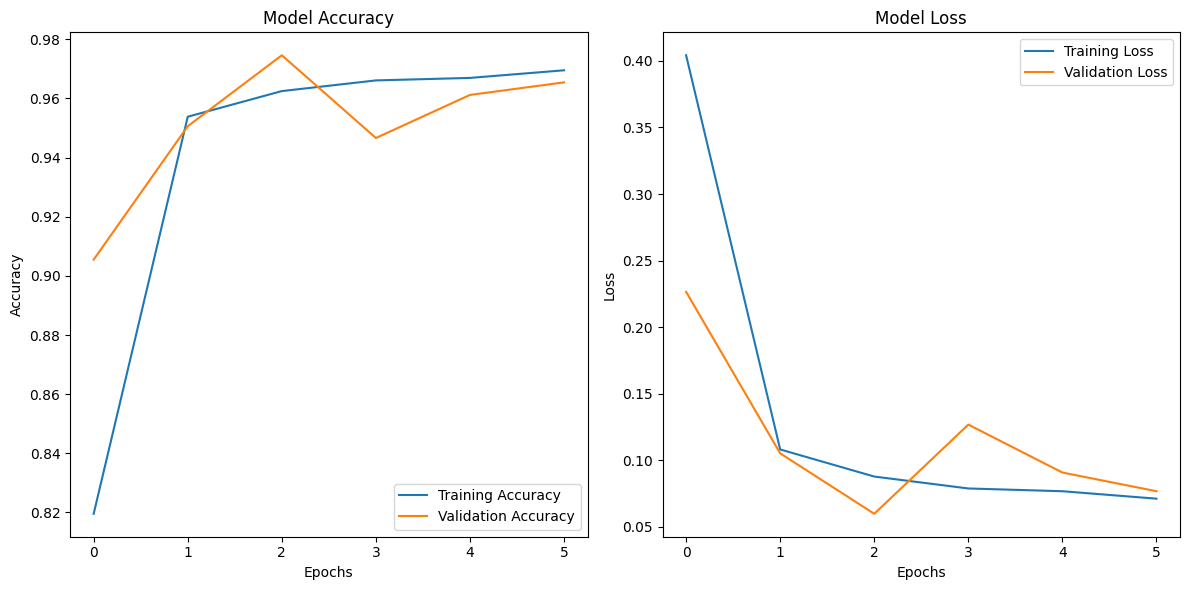

In [73]:
plt.figure(figsize=(12, 6)) 

plt.subplot(1, 2, 1) 
plt.plot(history.history['accuracy'], label='Training Accuracy') 
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') 
plt.title('Model Accuracy') 
plt.xlabel('Epochs') 
plt.ylabel('Accuracy') 
plt.legend() 

plt.subplot(1, 2, 2) 
plt.plot(history.history['loss'], label='Training Loss') 
plt.plot(history.history['val_loss'], label='Validation Loss') 
plt.title('Model Loss') 
plt.xlabel('Epochs') 
plt.ylabel('Loss') 
plt.legend() 
 
plt.tight_layout() 
plt.show()

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     34787
           1       0.95      0.98      0.96     50331
           2       0.98      0.95      0.97     54125
           3       0.99      0.98      0.99     60757

    accuracy                           0.97    200000
   macro avg       0.97      0.97      0.97    200000
weighted avg       0.97      0.97      0.97    200000



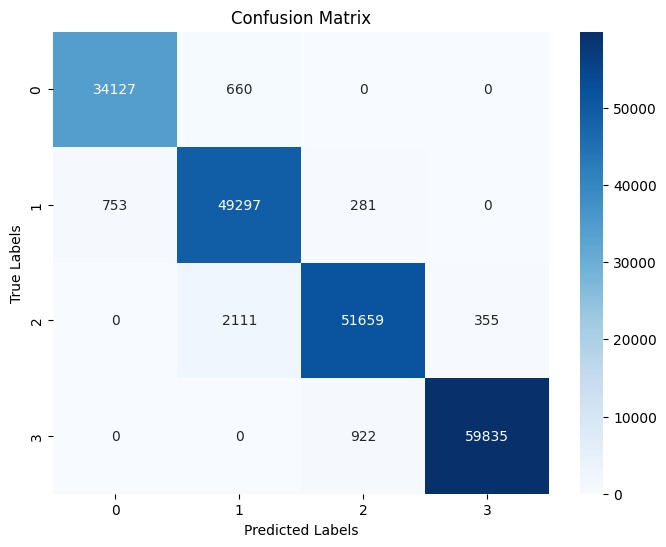

In [74]:
y_pred_probs = model.predict(x_val)
y_pred = np.argmax(y_pred_probs, axis=1)

print("--- Classification Report ---")
print(classification_report(y_val, y_pred))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

- ##### **Exceptional Balance: All F1-Score values are very high (between 0.96 and 0.99), indicating that the neural network was able to understand the four categories in a perfectly balanced and unbiased manner.**

- ##### **Prediction Accuracy: Category (3) is the strongest, as in previous models, with an accuracy of 99%.**

- ##### **Overlap: The confusion matrix shows high "purity" in the main diagonal. There is very little overlap between categories (1) and (2), where 2111 samples from category 2 were incorrectly classified as category 1, which is expected given the likely similarity in user behavior at these levels.**

In [75]:
with open('dnn_model.pkl' , 'wb') as f :
   pickle.dump(model, f)

---------------------------------------------
## **Test**
---------------------------------------------

In [76]:
data_test = pd.read_excel('/kaggle/working/data_for_test.xlsx')
data_test.head()

,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,sleep_hours_per_night,...,time_on_reels_per_day,average_session_length_minutes,content_type_preference,preferred_content_theme,perceived_stress_score,age_of_account,engagement_seg,age_group,reels_watch_segment,usage_level
0,Male,Germany,Urban,Middle,Student,High school,Single,No,10.1,7.0,...,25,23.8,Live,Music,18,14,Power Users,Middle,Binge Watcher,Regular
1,Female,Other,Urban,Middle,Freelancer,High school,Single,No,17.8,6.4,...,25,10.0,Live,Fitness,15,4,Power Users,Middle,Binge Watcher,Active
2,Male,India,Rural,Lower-middle,Student,Master’s,Single,Yes,9.6,8.0,...,51,29.5,Reels,Travel,24,1,Passive Users,Middle,Binge Watcher,Power User
3,Female,India,Suburban,Lower-middle,Full-time employed,High school,Single,No,5.9,6.5,...,77,22.8,Reels,Fashion,29,14,Casual Users,Middle,Binge Watcher,Power User
4,Female,United Kingdom,Urban,Middle,Unemployed,High school,Married,No,4.2,7.8,...,101,30.9,Photos,Travel,16,14,Passive Users,Adult,Binge Watcher,Power User


In [77]:
d = {'Passive Users': 0, 'Casual Users': 1, 'Regular Users' : 2, 'Power Users' : 3}
data_test['engagement_seg'] = data_test['engagement_seg'].map(d)

In [78]:
original_data_test_cat = data_test.copy()
original_data_test_lgbm = data_test.copy()
original_data_test_rf = data_test.copy()
original_data_test_dnn = data_test.copy()

In [79]:
data_test = data_test.drop('engagement_seg',axis=1)

--------------------------------------------

In [80]:
with open('/kaggle/working/cat_pipeline.pkl','rb') as f : 
    cat_pipeline = pickle.load(f)

In [81]:
new_predictions1 = cat_pipeline.predict(data_test)

In [82]:
new_predictions1.shape

(200, 1)

In [83]:
#new_predictions1 = new_predictions1.ravel()
#new_predictions1.shape

In [84]:
original_data_test_cat['engagement_seg_predicted'] = new_predictions1

In [85]:
original_data_test_cat[['engagement_seg','engagement_seg_predicted']]

,engagement_seg,engagement_seg_predicted
0,3,3
1,3,3
2,0,0
3,1,1
4,0,0
...,...,...
195,3,3
196,1,1
197,0,0
198,0,0


-------------------------------------

In [86]:
with open('/kaggle/working/lgbm_pipeline.pkl','rb') as f : 
    lgbm_pipeline = pickle.load(f)

In [87]:
new_predictions2 = lgbm_pipeline.predict(data_test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [88]:
original_data_test_lgbm['engagement_seg_predicted'] = new_predictions2

In [89]:
original_data_test_lgbm[['engagement_seg','engagement_seg_predicted']]

,engagement_seg,engagement_seg_predicted
0,3,3
1,3,3
2,0,0
3,1,1
4,0,0
...,...,...
195,3,3
196,1,1
197,0,0
198,0,0


--------------------------------------------

In [90]:
with open('/kaggle/working/rf_pipeline.pkl','rb') as f : 
    rf_pipeline = pickle.load(f)

In [91]:
new_predictions3 = rf_pipeline.predict(data_test)

In [92]:
original_data_test_rf['engagement_seg_predicted'] = new_predictions3

In [93]:
original_data_test_rf[['engagement_seg','engagement_seg_predicted']]

,engagement_seg,engagement_seg_predicted
0,3,3
1,3,3
2,0,0
3,1,1
4,0,0
...,...,...
195,3,3
196,1,1
197,0,0
198,0,0


---------------------------------

In [94]:
with open('dnn_model.pkl','rb') as f : 
    dnn_model = pickle.load(f)

In [95]:
with open('/kaggle/working/ordinal_encoder.pkl','rb') as f : 
    ordinal_encoder = pickle.load(f)

In [96]:
data_test[cats_cols] = ordinal_encoder.transform(data_test[cats_cols])

In [97]:
with open('/kaggle/working/sclaer.pkl','rb') as f : 
    scaler = pickle.load(f)

In [98]:
data_test[num_cols] = scaler.transform(data_test[num_cols])

In [99]:
new_predictions4 = dnn_model.predict(data_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [100]:
final_predictions = np.argmax(new_predictions4, axis=1)

In [101]:
final_predictions.shape

(200,)

In [102]:
original_data_test_dnn['engagement_seg_predicted'] = final_predictions

In [109]:
original_data_test_dnn[['engagement_seg','engagement_seg_predicted']].sample(10)

,engagement_seg,engagement_seg_predicted
68,0,0
25,2,2
20,0,0
95,2,2
9,2,2
15,3,3
154,2,2
31,3,3
33,0,0
81,2,2


In [104]:
# original_data_test_dnn.to_excel('prediction_data.xlsx',index=False)

----------------------------------


# <center><strong>Conclusion</strong></center>
--------------------------------------------
- ##### **Model Efficiency: The results showed the remarkable superiority of the Deep Neural Network (DNN) and LightGBM models, achieving an overall accuracy of 97%, confirming their high ability to extract complex and nonlinear patterns in user behavior.**

- ##### **Category Analysis: The project successfully delivered accurate and balanced classification across four main categories, providing valuable insights that can be used to improve user experience and develop customized recommendation algorithms.**

- ##### **Scalability: Thanks to training on a massive database (200,000 samples), the system demonstrated high stability and reliability, making it production-ready for real-world applications.**

---------------------------------------

In [ ]:
# !jupyter nbconvert --to html "social-media-user-classification.ipynb"

[NbConvertApp] Converting notebook social-media-user-classification.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 65 image(s).
[NbConvertApp] Writing 6578051 bytes to social-media-user-classification.html
